In [103]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_ind
import plotly.graph_objects as go


In [104]:
# plt.rcParams.update({'font.size': 14})  

# Compare treatment vs. control questionnaire
# Did eye-tracking affect people's experience?

In [105]:
control_df  = pd.read_csv("questionnaire_control.csv")
eye_tracker_df  = pd.read_csv("questionnaire_treatment.csv")
eye_tracking_data = pd.read_csv("eye_tracking.csv")

In [106]:
eye_tracker_df['Cubes Emotion Mean'] = eye_tracker_df[['Matter Emotions', 'Matter Emotions', 'Matter Emotions']].mean(axis=1)
eye_tracker_df['Cubes Learning Mean'] = eye_tracker_df[['Matter Learning', 'Matter Learning', 'Matter Learning']].mean(axis=1)

control_df['Cubes Emotion Mean'] = control_df[['Matter Emotions', 'Matter Emotions', 'Matter Emotions']].mean(axis=1)
control_df['Cubes Learning Mean'] = control_df[['Matter Learning', 'Matter Learning', 'Matter Learning']].mean(axis=1)

In [107]:
control_df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 47 columns):
 #   Column                                                                             Non-Null Count  Dtype  
---  ------                                                                             --------------  -----  
 0   Start time                                                                         146 non-null    object 
 1   ID                                                                                 146 non-null    object 
 2   Matter Emotions                                                                    145 non-null    float64
 3   Life Emotions                                                                      145 non-null    float64
 4   Thought Emotions                                                                   145 non-null    float64
 5   Matter Learning                                                                    145 non-null    float64

In [108]:
control_df.head()

,Start time,ID,Matter Emotions,Life Emotions,Thought Emotions,Matter Learning,Life Learning,Thought Learning,Admiration,Confusion,...,Age group,Gender,Race,Do you have any disabilities?,What disability do you have?,Do you have children?,Where do you live?,Would you like to share something more about your visit or your experience today?,Cubes Emotion Mean,Cubes Learning Mean
0,2023-09-25 21:54:11,D05-P009,NaN,NaN,NaN,NaN,NaN,NaN,3,5,...,31-59 anos,Masculino,Outro,NaN,NaN,Não,Cidade do Rio,NaN,NaN,NaN
1,2023-09-26 16:11:42,D05-P001,4.0,4.0,3.0,3.0,5.0,4.0,5,3,...,19-30 anos,Feminino,Amarelo,Sim,Outra,Não,Cidade do Rio,NaN,4.0,3.0
2,2023-09-26 16:33:48,D03-P010,8.0,4.0,8.0,5.0,4.0,8.0,8,1,...,31-59 anos,Feminino,Pardo,Não,NaN,Não,Outro Estado do Brasil,Foi uma das experiencias mais incriveis que ja...,8.0,5.0
3,2023-09-26 17:00:56,D05-P010,6.0,8.0,8.0,5.0,7.0,8.0,8,1,...,19-30 anos,Feminino,Pardo,Não,NaN,Não,Outro Estado do Brasil,Admirei muito a visitacao. Super contente,6.0,5.0
4,2023-09-26 19:36:08,D04-P017,8.0,8.0,1.0,8.0,7.0,2.0,8,5,...,19-30 anos,Feminino,Branco,Não,NaN,Não,Outro País,NaN,8.0,8.0


In [109]:
eye_tracker_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 47 columns):
 #   Column                                                                             Non-Null Count  Dtype  
---  ------                                                                             --------------  -----  
 0   Start time                                                                         170 non-null    object 
 1   ID                                                                                 170 non-null    object 
 2   Matter Emotions                                                                    170 non-null    float64
 3   Life Emotions                                                                      170 non-null    float64
 4   Thought Emotions                                                                   170 non-null    float64
 5   Matter Learning                                                                    170 non-null    float64

In [110]:
control_df['Group'] = 'Control'
eye_tracker_df['Group'] = 'Eye-Tracking'

control_df = control_df.dropna(subset=['Matter Emotions'])

control_df.reset_index(drop=True, inplace=True)
eye_tracker_df.reset_index(drop=True, inplace=True)

combined_df = pd.concat([control_df, eye_tracker_df], axis=0)

combined_df.reset_index(drop=True, inplace=True)

combined_df

,Start time,ID,Matter Emotions,Life Emotions,Thought Emotions,Matter Learning,Life Learning,Thought Learning,Admiration,Confusion,...,Gender,Race,Do you have any disabilities?,What disability do you have?,Do you have children?,Where do you live?,Would you like to share something more about your visit or your experience today?,Cubes Emotion Mean,Cubes Learning Mean,Group
0,2023-09-26 16:11:42,D05-P001,4.0,4.0,3.0,3.0,5.0,4.0,5,3,...,Feminino,Amarelo,Sim,Outra,Não,Cidade do Rio,NaN,4.0,3.0,Control
1,2023-09-26 16:33:48,D03-P010,8.0,4.0,8.0,5.0,4.0,8.0,8,1,...,Feminino,Pardo,Não,NaN,Não,Outro Estado do Brasil,Foi uma das experiencias mais incriveis que ja...,8.0,5.0,Control
2,2023-09-26 17:00:56,D05-P010,6.0,8.0,8.0,5.0,7.0,8.0,8,1,...,Feminino,Pardo,Não,NaN,Não,Outro Estado do Brasil,Admirei muito a visitacao. Super contente,6.0,5.0,Control
3,2023-09-26 19:36:08,D04-P017,8.0,8.0,1.0,8.0,7.0,2.0,8,5,...,Feminino,Branco,Não,NaN,Não,Outro País,NaN,8.0,8.0,Control
4,2023-09-27 17:33:42,D03-P032,6.0,8.0,8.0,8.0,8.0,8.0,8,1,...,Feminino,Branco,Não,NaN,Não,Outro País,Bellissima.,6.0,8.0,Control
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310,2023-10-01 23:02:26,D03-P066,6.0,8.0,5.0,6.0,5.0,6.0,8,1,...,Feminino,Pardo,Não,NaN,Não,Outro Estado do Brasil,NaN,6.0,6.0,Eye-Tracking
311,2023-10-01 23:15:33,D01-P063,6.0,8.0,7.0,6.0,8.0,7.0,7,4,...,Masculino,Preto,Não,NaN,Não,Outro Estado do Brasil,NaN,6.0,6.0,Eye-Tracking
312,2023-10-01 23:17:45,D05-P050,5.0,5.0,8.0,3.0,3.0,8.0,5,6,...,Feminino,Branco,Não,NaN,Não,Outro Estado do Brasil,NaN,5.0,3.0,Eye-Tracking
313,2023-10-01 23:44:36,D01-P064,8.0,8.0,8.0,8.0,8.0,8.0,8,3,...,Masculino,Branco,Não,NaN,Sim,Outro Estado do Brasil,NaN,8.0,8.0,Eye-Tracking


C:\Users\aslan\AppData\Local\Temp\ipykernel_10960\3689148382.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




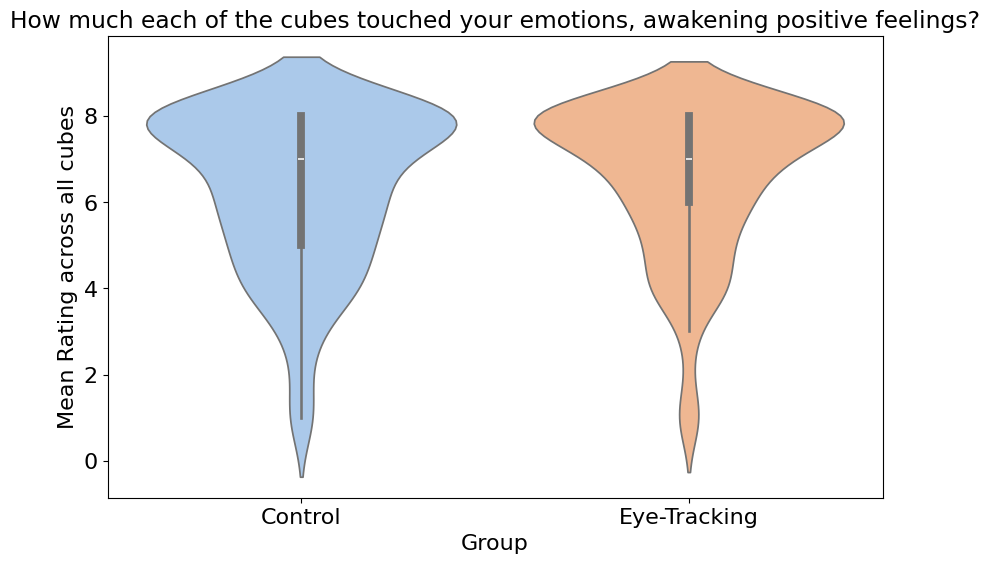

In [111]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Group', y='Cubes Emotion Mean', data=combined_df, palette='pastel')

plt.title('How much each of the cubes touched your emotions, awakening positive feelings?')
plt.xlabel('Group', fontsize = 16)
plt.ylabel('Mean Rating across all cubes', fontsize = 16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.show()

In [112]:
control_values = control_df['Cubes Emotion Mean']
treatment_values = eye_tracker_df['Cubes Emotion Mean']

control_mean = control_values.mean()
treatment_mean = treatment_values.mean()
control_median = control_values.median()
treatment_median = treatment_values.median()
control_std = control_values.std()
treatment_std = treatment_values.std()

print(f"Control Mean: {control_mean}, Treatment Mean: {treatment_mean}")
print(f"Control Median: {control_median}, Treatment Median: {treatment_median}")
print(f"Control Std: {control_std}, Treatment Std: {treatment_std}")

# Perform a t-test for independent samples
t_stat, p_value = stats.ttest_ind(control_values, treatment_values, equal_var=False)  # Welch’s t-test
print(f"t-test: t-statistic = {t_stat}, p-value = {p_value}")

# Perform a Mann-Whitney U test
u_stat, p_value_mwu = stats.mannwhitneyu(control_values, treatment_values, alternative='two-sided')
print(f"Mann-Whitney U test: U-statistic = {u_stat}, p-value = {p_value_mwu}")


Control Mean: 6.2827586206896555, Treatment Mean: 6.570588235294117
Control Median: 7.0, Treatment Median: 7.0
Control Std: 1.8510636892363255, Treatment Std: 1.7602664893334303
t-test: t-statistic = -1.4068568375157924, p-value = 0.1605055546219527
Mann-Whitney U test: U-statistic = 11206.5, p-value = 0.1475087906694873


C:\Users\aslan\AppData\Local\Temp\ipykernel_10960\1236795084.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




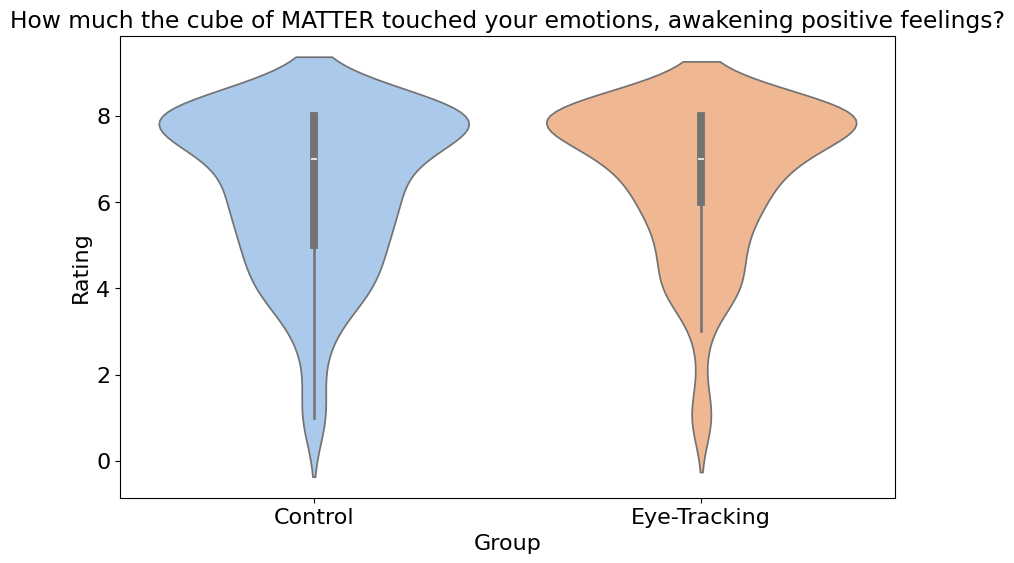

In [113]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Group', y='Matter Emotions', data=combined_df, palette='pastel')

plt.title('How much the cube of MATTER touched your emotions, awakening positive feelings?')
plt.xlabel('Group', fontsize = 16)
plt.ylabel('Rating', fontsize = 16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.show()

C:\Users\aslan\AppData\Local\Temp\ipykernel_10960\3091272479.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




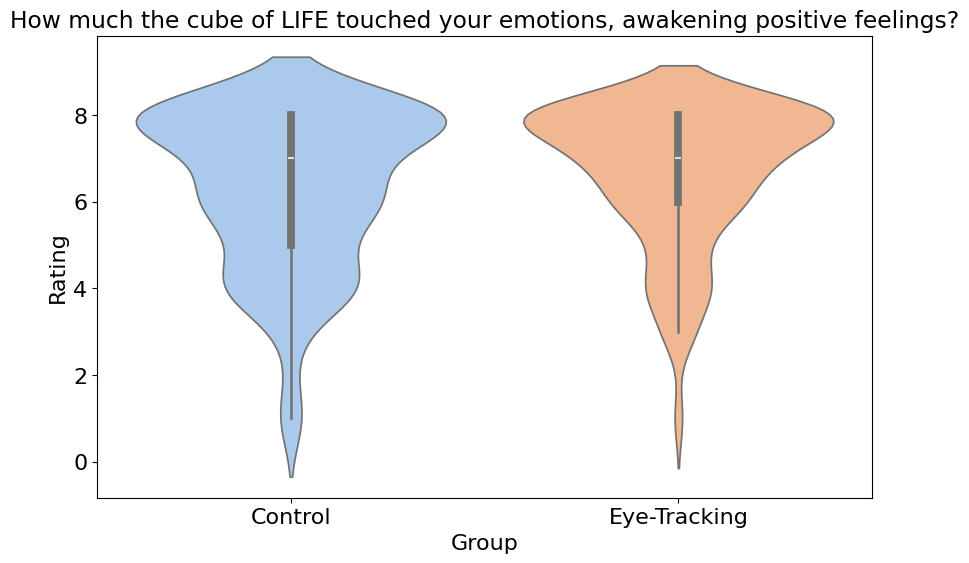

In [114]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Group', y='Life Emotions', data=combined_df, palette='pastel')

plt.title('How much the cube of LIFE touched your emotions, awakening positive feelings?')
plt.xlabel('Group', fontsize=16)
plt.ylabel('Rating', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.show()

C:\Users\aslan\AppData\Local\Temp\ipykernel_10960\688477185.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




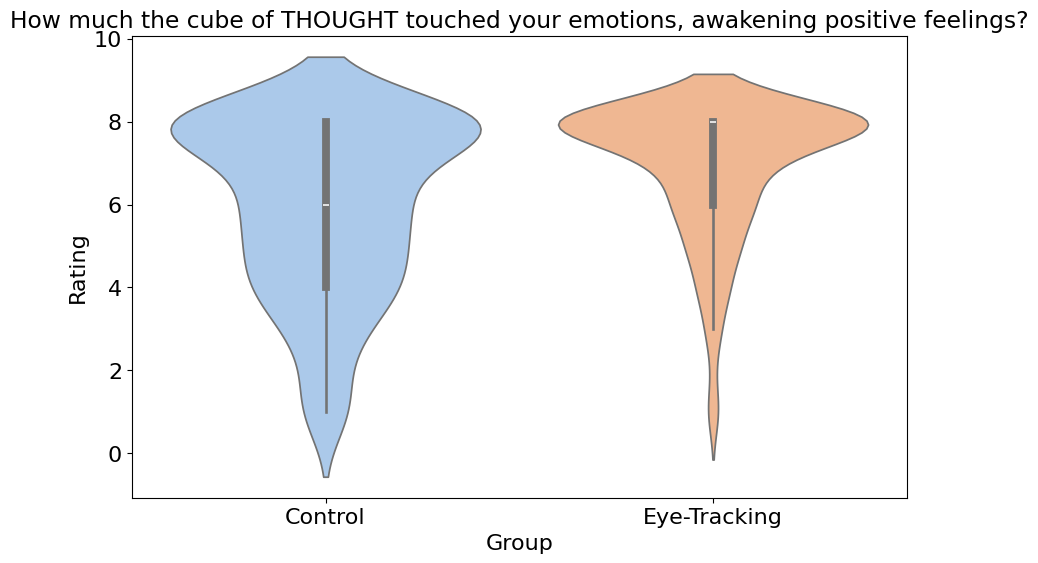

In [115]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Group', y='Thought Emotions', data=combined_df, palette='pastel')

plt.title('How much the cube of THOUGHT touched your emotions, awakening positive feelings?')
plt.xlabel('Group', fontsize=16)
plt.ylabel('Rating', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.show()

In [116]:
control_values = combined_df[combined_df['Group'] == 'Control']['Thought Emotions']
treatment_values = combined_df[combined_df['Group'] == 'Eye-Tracking']['Thought Emotions']

control_mean = control_values.mean()
treatment_mean = treatment_values.mean()
control_median = control_values.median()
treatment_median = treatment_values.median()
control_std = control_values.std()
treatment_std = treatment_values.std()

print(f"Control Mean: {control_mean}, Treatment Mean: {treatment_mean}")
print(f"Control Median: {control_median}, Treatment Median: {treatment_median}")
print(f"Control Std: {control_std}, Treatment Std: {treatment_std}")

# Perform a t-test for independent samples
t_stat, p_value = stats.ttest_ind(control_values, treatment_values, equal_var=False)  # Welch’s t-test
print(f"t-test: t-statistic = {t_stat}, p-value = {p_value}")

# Perform a Mann-Whitney U test
u_stat, p_value_mwu = stats.mannwhitneyu(control_values, treatment_values, alternative='two-sided')
print(f"Mann-Whitney U test: U-statistic = {u_stat}, p-value = {p_value_mwu}")


Control Mean: 5.9655172413793105, Treatment Mean: 6.923529411764706
Control Median: 6.0, Treatment Median: 8.0
Control Std: 2.11612129819134, Treatment Std: 1.6062118364732814
t-test: t-statistic = -4.463915928192118, p-value = 1.1903753769183402e-05
Mann-Whitney U test: U-statistic = 9112.0, p-value = 2.2317225056101027e-05


C:\Users\aslan\AppData\Local\Temp\ipykernel_10960\1475767079.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




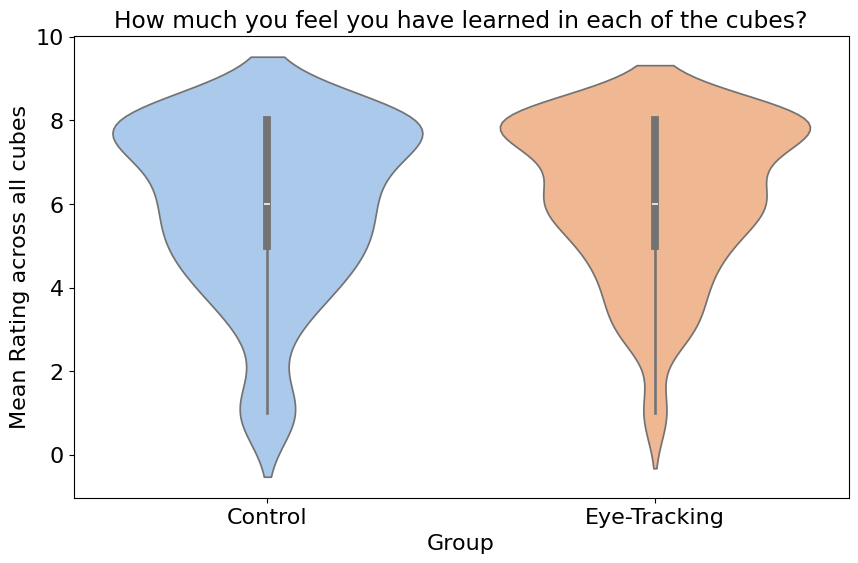

In [117]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Group', y='Cubes Learning Mean', data=combined_df, palette='pastel')

plt.title('How much you feel you have learned in each of the cubes?')
plt.xlabel('Group', fontsize=16)
plt.ylabel('Mean Rating across all cubes', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.show()

In [118]:
control_values = control_df['Cubes Learning Mean']
treatment_values = eye_tracker_df['Cubes Learning Mean']

# Calculate basic statistics
control_mean = control_values.mean()
treatment_mean = treatment_values.mean()
control_median = control_values.median()
treatment_median = treatment_values.median()
control_std = control_values.std()
treatment_std = treatment_values.std()

print(f"Control Mean: {control_mean}, Treatment Mean: {treatment_mean}")
print(f"Control Median: {control_median}, Treatment Median: {treatment_median}")
print(f"Control Std: {control_std}, Treatment Std: {treatment_std}")

# Perform a t-test for independent samples
t_stat, p_value = stats.ttest_ind(control_values, treatment_values, equal_var=False)  # Welch’s t-test
print(f"t-test: t-statistic = {t_stat}, p-value = {p_value}")

# Perform a Mann-Whitney U test
u_stat, p_value_mwu = stats.mannwhitneyu(control_values, treatment_values, alternative='two-sided')
print(f"Mann-Whitney U test: U-statistic = {u_stat}, p-value = {p_value_mwu}")


Control Mean: 5.944827586206896, Treatment Mean: 6.182352941176471
Control Median: 6.0, Treatment Median: 6.0
Control Std: 2.0608092745085322, Treatment Std: 1.845107169356679
t-test: t-statistic = -1.0695954284361993, p-value = 0.28568498603249126
Mann-Whitney U test: U-statistic = 11674.0, p-value = 0.4070899002508577


C:\Users\aslan\AppData\Local\Temp\ipykernel_10960\91637185.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




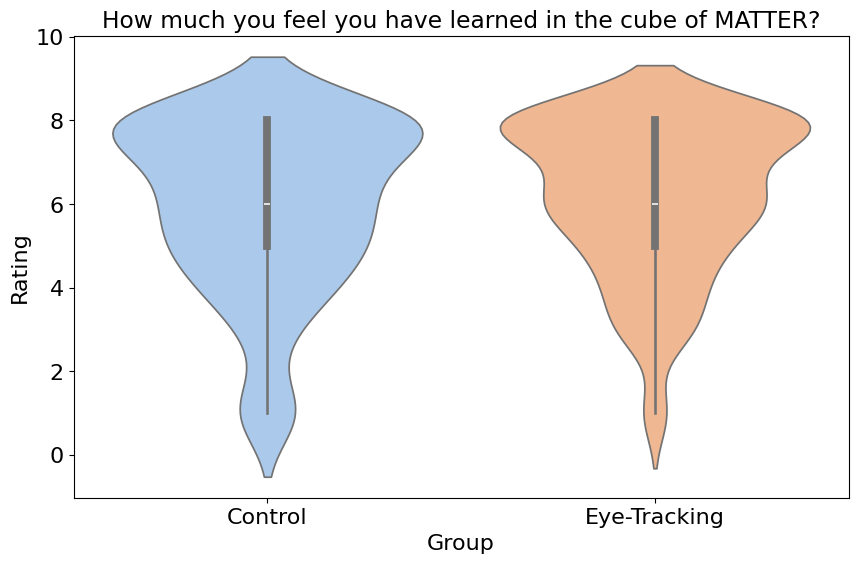

In [119]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Group', y='Matter Learning', data=combined_df, palette='pastel')

plt.title('How much you feel you have learned in the cube of MATTER?')
plt.xlabel('Group', fontsize=16)
plt.ylabel('Rating', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.show()

C:\Users\aslan\AppData\Local\Temp\ipykernel_10960\2869871861.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




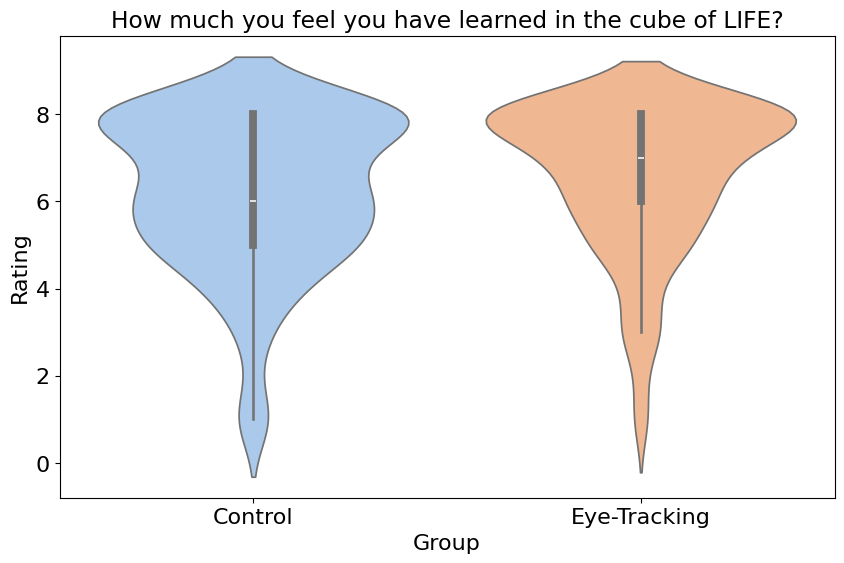

In [120]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Group', y='Life Learning', data=combined_df, palette='pastel')

plt.title('How much you feel you have learned in the cube of LIFE?')
plt.xlabel('Group', fontsize=16)
plt.ylabel('Rating', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.show()

C:\Users\aslan\AppData\Local\Temp\ipykernel_10960\781493267.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




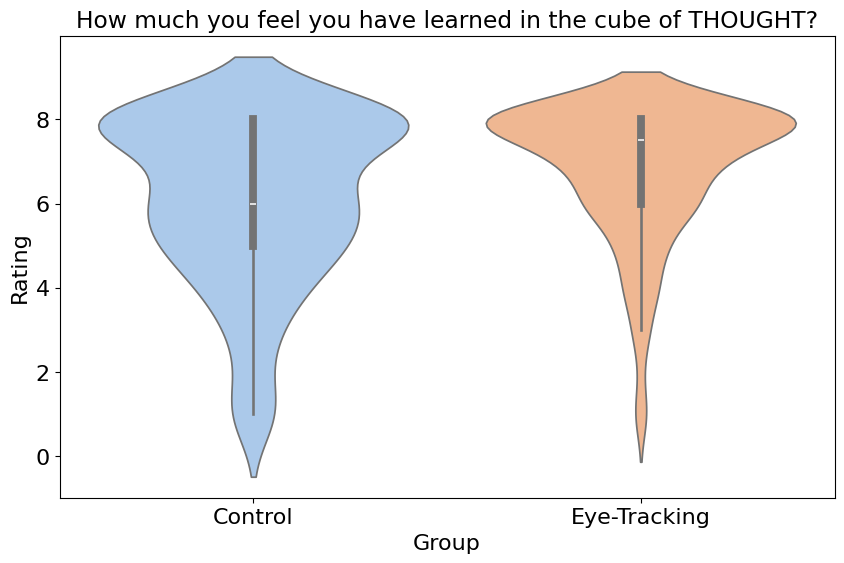

In [121]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Group', y='Thought Learning', data=combined_df, palette='pastel')

plt.title('How much you feel you have learned in the cube of THOUGHT?')
plt.xlabel('Group', fontsize=16)
plt.ylabel('Rating', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.show()

In [122]:
control_values = combined_df[combined_df['Group'] == 'Control']['Thought Learning']
treatment_values = combined_df[combined_df['Group'] == 'Eye-Tracking']['Thought Learning']

control_mean = control_values.mean()
treatment_mean = treatment_values.mean()
control_median = control_values.median()
treatment_median = treatment_values.median()
control_std = control_values.std()
treatment_std = treatment_values.std()

print(f"Control Mean: {control_mean}, Treatment Mean: {treatment_mean}")
print(f"Control Median: {control_median}, Treatment Median: {treatment_median}")
print(f"Control Std: {control_std}, Treatment Std: {treatment_std}")

# Perform a t-test for independent samples
t_stat, p_value = stats.ttest_ind(control_values, treatment_values, equal_var=False)  # Welch’s t-test
print(f"t-test: t-statistic = {t_stat}, p-value = {p_value}")

# Perform a Mann-Whitney U test
u_stat, p_value_mwu = stats.mannwhitneyu(control_values, treatment_values, alternative='two-sided')
print(f"Mann-Whitney U test: U-statistic = {u_stat}, p-value = {p_value_mwu}")


Control Mean: 6.089655172413793, Treatment Mean: 6.847058823529411
Control Median: 6.0, Treatment Median: 7.5
Control Std: 2.006646045641937, Treatment Std: 1.5764981217496787
t-test: t-statistic = -3.6787313055902406, p-value = 0.0002826057040372506
Mann-Whitney U test: U-statistic = 9692.5, p-value = 0.0005870090694799704


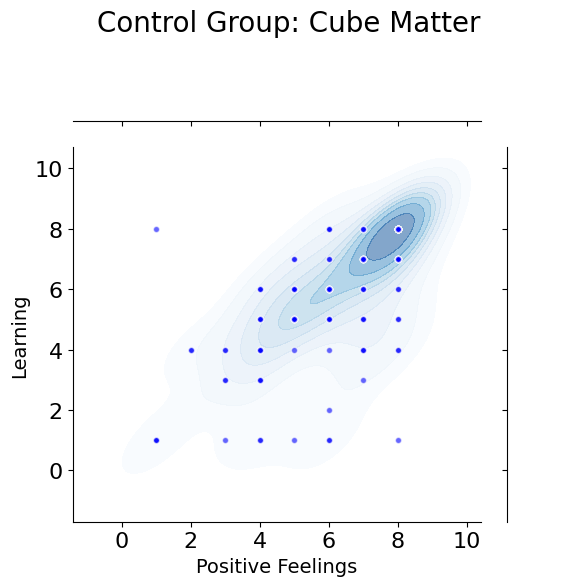

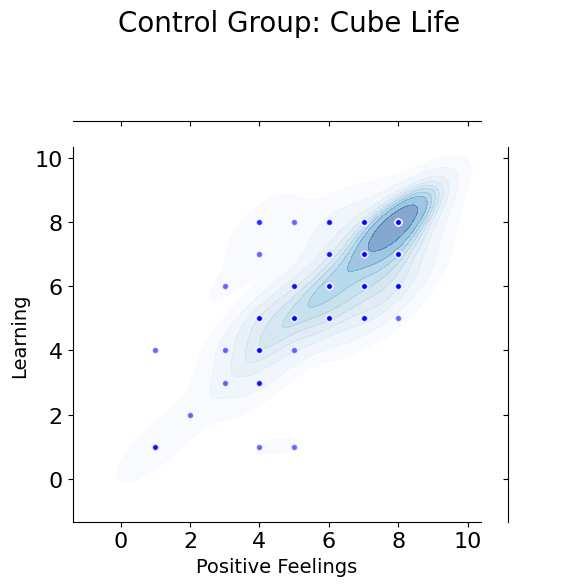

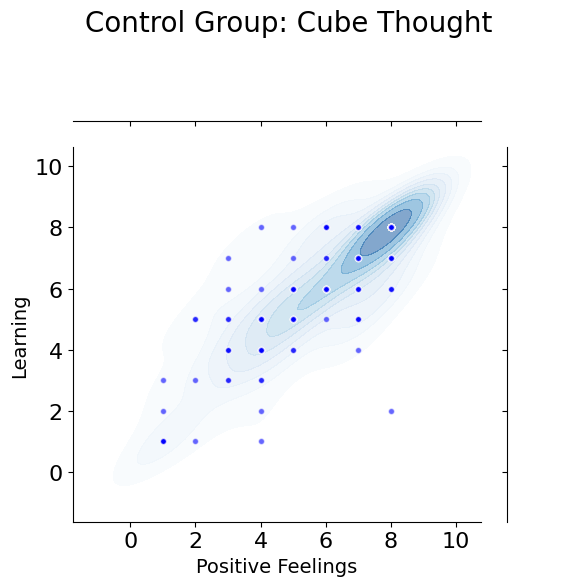

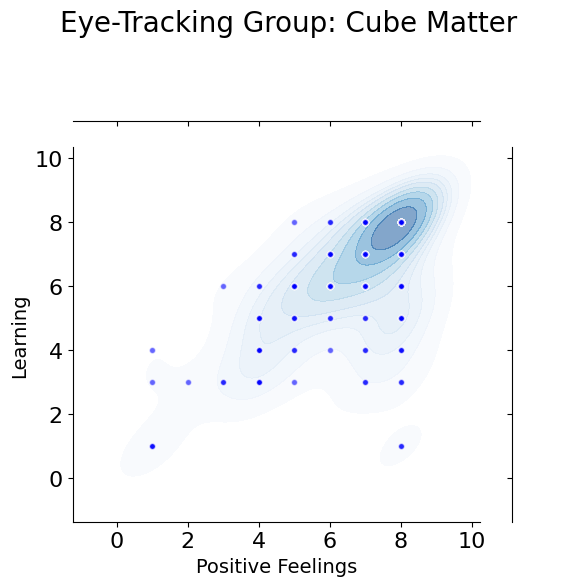

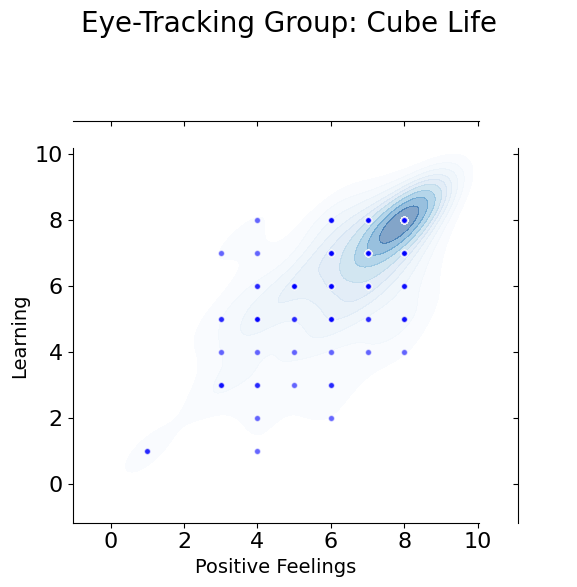

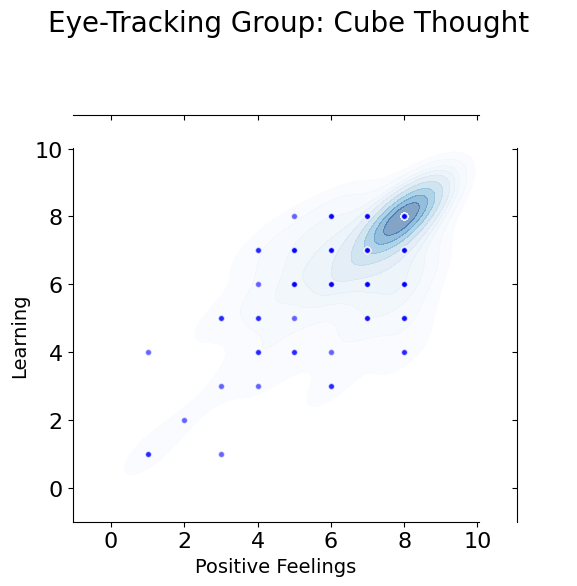

In [123]:
title_mapping = {
    'Matter Emotions': 'Cube Matter',
    'Life Emotions': 'Cube Life',
    'Thought Emotions': 'Cube Thought'
}
# Function to create joint plots for a given group without marginal plots
def plot_group_data(group_df, group_name):
    pairs = [
        ('Matter Emotions', 'Matter Learning'),
        ('Life Emotions', 'Life Learning'),
        ('Thought Emotions', 'Thought Learning')
    ]

    for emotion_col, learning_col in pairs:
        # Initialize the JointGrid
        g = sns.JointGrid(data=group_df, x=emotion_col, y=learning_col)

        # Plot the main joint KDE plot
        g.plot_joint(sns.kdeplot, fill=True, cmap="Blues", alpha=0.5)
        
        # Optionally add scatter plot overlay
        g.ax_joint.scatter(group_df[emotion_col], group_df[learning_col], color='blue', edgecolor='w', s=20, alpha=0.6)
        
        g.ax_joint.set_xlabel(emotion_col, fontsize=20)
        g.ax_joint.set_ylabel(learning_col, fontsize=20)

        # Set font size for tick labels
        g.ax_joint.tick_params(axis='both', labelsize=16)

        ticks = [0, 2, 4, 6, 8, 10]
        g.ax_joint.set_xticks(ticks)
        g.ax_joint.set_yticks(ticks)


        g.ax_joint.set_xlabel('Positive Feelings', fontsize=14)
        g.ax_joint.set_ylabel('Learning', fontsize=14)

        # Setting the title
        title = f'{group_name} Group: {title_mapping[emotion_col]}'
        g.fig.suptitle(title, fontsize=20)
        # Adjust layout to prevent title cutoff
        g.fig.tight_layout()
        
        # Show the plot
        plt.show()

# Create plots for 'Control' and 'Eye-Tracking' groups
plot_group_data(control_df, 'Control')
plot_group_data(eye_tracker_df, 'Eye-Tracking')



# now let's explore eye-tracker wearers' behavior

In [124]:
eye_tracker_df

,Start time,ID,Matter Emotions,Life Emotions,Thought Emotions,Matter Learning,Life Learning,Thought Learning,Admiration,Confusion,...,Gender,Race,Do you have any disabilities?,What disability do you have?,Do you have children?,Where do you live?,Would you like to share something more about your visit or your experience today?,Cubes Emotion Mean,Cubes Learning Mean,Group
0,2023-09-26 16:34:00,D03-P011,8.0,3.0,6.0,5.0,7.0,7.0,8,3,...,Feminino,Pardo,Não,NaN,Não,Outro Estado do Brasil,NaN,8.0,5.0,Eye-Tracking
1,2023-09-26 16:59:30,D03-P012,7.0,7.0,7.0,7.0,7.0,7.0,8,1,...,Feminino,Pardo,Não,NaN,Não,Cidade do Rio,Adorei a esperiencia,7.0,7.0,Eye-Tracking
2,2023-09-26 17:19:10,D05-P013,4.0,6.0,8.0,3.0,5.0,7.0,5,2,...,Masculino,Branco,Não,NaN,Não,Cidade do Rio,NaN,4.0,3.0,Eye-Tracking
3,2023-09-26 17:27:36,D05-P014,7.0,6.0,8.0,6.0,7.0,8.0,8,4,...,Feminino,Branco,Não,NaN,Não,Outro Estado do Brasil,Experiencia maravilhosa,7.0,6.0,Eye-Tracking
4,2023-09-26 17:26:13,D03-P013,8.0,8.0,8.0,8.0,8.0,5.0,8,1,...,Feminino,Branco,Não,NaN,Não,Outro Estado do Brasil,Senti um pouco de náusea no cubo 3.,8.0,8.0,Eye-Tracking
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,2023-10-01 23:02:26,D03-P066,6.0,8.0,5.0,6.0,5.0,6.0,8,1,...,Feminino,Pardo,Não,NaN,Não,Outro Estado do Brasil,NaN,6.0,6.0,Eye-Tracking
166,2023-10-01 23:15:33,D01-P063,6.0,8.0,7.0,6.0,8.0,7.0,7,4,...,Masculino,Preto,Não,NaN,Não,Outro Estado do Brasil,NaN,6.0,6.0,Eye-Tracking
167,2023-10-01 23:17:45,D05-P050,5.0,5.0,8.0,3.0,3.0,8.0,5,6,...,Feminino,Branco,Não,NaN,Não,Outro Estado do Brasil,NaN,5.0,3.0,Eye-Tracking
168,2023-10-01 23:44:36,D01-P064,8.0,8.0,8.0,8.0,8.0,8.0,8,3,...,Masculino,Branco,Não,NaN,Sim,Outro Estado do Brasil,NaN,8.0,8.0,Eye-Tracking


In [125]:
eye_tracker_df = pd.merge(eye_tracker_df, eye_tracking_data, on='ID', how='inner')
eye_tracker_df = eye_tracker_df[eye_tracker_df['has_corruption'] == False]

In [126]:
eye_tracker_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 136 entries, 0 to 169
Data columns (total 73 columns):
 #   Column                                                                             Non-Null Count  Dtype  
---  ------                                                                             --------------  -----  
 0   Start time                                                                         136 non-null    object 
 1   ID                                                                                 136 non-null    object 
 2   Matter Emotions                                                                    136 non-null    float64
 3   Life Emotions                                                                      136 non-null    float64
 4   Thought Emotions                                                                   136 non-null    float64
 5   Matter Learning                                                                    136 non-null    float64
 6  

In [127]:
eye_tracker_df.head()

,Start time,ID,Matter Emotions,Life Emotions,Thought Emotions,Matter Learning,Life Learning,Thought Learning,Admiration,Confusion,...,overall_duration,weekday,overall_panel_duration,number_of_panels,matter_panel_num,life_panel_num,thought_panel_num,matter_panel_duration,life_panel_duration,thought_panel_duration
0,2023-09-26 16:34:00,D03-P011,8.0,3.0,6.0,5.0,7.0,7.0,8,3,...,17.313833,Tuesday,2.340924,2,0,2,0,0.000000,2.340924,0.0
1,2023-09-26 16:59:30,D03-P012,7.0,7.0,7.0,7.0,7.0,7.0,8,1,...,16.004833,Tuesday,0.000000,0,0,0,0,0.000000,0.000000,0.0
2,2023-09-26 17:19:10,D05-P013,4.0,6.0,8.0,3.0,5.0,7.0,5,2,...,17.079667,Tuesday,1.523487,2,0,1,0,0.000000,0.920437,0.0
3,2023-09-26 17:27:36,D05-P014,7.0,6.0,8.0,6.0,7.0,8.0,8,4,...,11.662333,Tuesday,0.000000,0,0,0,0,0.000000,0.000000,0.0
4,2023-09-26 17:26:13,D03-P013,8.0,8.0,8.0,8.0,8.0,5.0,8,1,...,25.940733,Tuesday,1.668494,2,1,1,0,1.015088,0.653407,0.0


In [128]:
print(eye_tracker_df[eye_tracker_df['has_corruption'] == True])

Empty DataFrame
Columns: [Start time, ID, Matter Emotions, Life Emotions, Thought Emotions, Matter Learning, Life Learning, Thought Learning, Admiration, Confusion, Haunt, Disorientation, Amazement, Fascination, Amazing, Curiosity, Perplexity, I felt a closer sense of identity, of who I am., I felt a psychological connection to everyone/everything around me., I felt a physical connection to everyone/everything around me., Everything seemed to be connected., I experienced a feeling of confinement., I experienced a feeling of oppression., I experienced a feeling of tension., My heart was racing., It took my breath away., I felt chills., I felt physically smaller., I felt trivial, in the grand scheme of things., The world seemed vast., What did you learn about during your visit?, Is this your first time visiting the Museum of Tomorrow?, If not, how many times have you visited us previously?, Did you watch the movie Cosmos, projected onto the sphere?, How many people accompanied you on thi

In [129]:
percentage_columns = [
    'p1_duration', 'p2_duration', 'p3_duration', 'p4_duration', 'p5_duration', 'p6_duration', 'p7_duration',
    'matter_panel_duration', 'life_panel_duration', 'thought_panel_duration', 'overall_panel_duration'
]

for col in percentage_columns:
    percentage_col_name = col.replace('duration', 'percentage')  # Change the name to 'percentage'
    eye_tracker_df[percentage_col_name] = eye_tracker_df[col] / eye_tracker_df['overall_duration']

eye_tracker_df['interactive_panel_duration'] = eye_tracker_df['p1_duration'] + eye_tracker_df['p3_duration'] + eye_tracker_df['p5_duration'] + eye_tracker_df['p7_duration']

eye_tracker_df['noninteractive_panel_duration'] = eye_tracker_df['p2_duration'] + eye_tracker_df['p4_duration'] + eye_tracker_df['p6_duration'] 

eye_tracker_df['interactive_panel_percentage'] = eye_tracker_df['interactive_panel_duration'] / eye_tracker_df['overall_duration']
eye_tracker_df['noninteractive_panel_percentage'] = eye_tracker_df['noninteractive_panel_duration'] / eye_tracker_df['overall_duration']



In [130]:
eye_tracker_df.info()
eye_tracker_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 136 entries, 0 to 169
Data columns (total 88 columns):
 #   Column                                                                             Non-Null Count  Dtype  
---  ------                                                                             --------------  -----  
 0   Start time                                                                         136 non-null    object 
 1   ID                                                                                 136 non-null    object 
 2   Matter Emotions                                                                    136 non-null    float64
 3   Life Emotions                                                                      136 non-null    float64
 4   Thought Emotions                                                                   136 non-null    float64
 5   Matter Learning                                                                    136 non-null    float64
 6  

,Start time,ID,Matter Emotions,Life Emotions,Thought Emotions,Matter Learning,Life Learning,Thought Learning,Admiration,Confusion,...,p6_percentage,p7_percentage,matter_panel_percentage,life_panel_percentage,thought_panel_percentage,overall_panel_percentage,interactive_panel_duration,noninteractive_panel_duration,interactive_panel_percentage,noninteractive_panel_percentage
0,2023-09-26 16:34:00,D03-P011,8.0,3.0,6.0,5.0,7.0,7.0,8,3,...,0.0,0.0,0.000000,0.135205,0.0,0.135205,0.816848,1.524076,0.047179,0.088026
1,2023-09-26 16:59:30,D03-P012,7.0,7.0,7.0,7.0,7.0,7.0,8,1,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2,2023-09-26 17:19:10,D05-P013,4.0,6.0,8.0,3.0,5.0,7.0,5,2,...,0.0,0.0,0.000000,0.053891,0.0,0.089199,0.603050,0.920437,0.035308,0.053891
3,2023-09-26 17:27:36,D05-P014,7.0,6.0,8.0,6.0,7.0,8.0,8,4,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
4,2023-09-26 17:26:13,D03-P013,8.0,8.0,8.0,8.0,8.0,5.0,8,1,...,0.0,0.0,0.039131,0.025188,0.0,0.064319,0.000000,1.668494,0.000000,0.064319


# which panels were more popular?

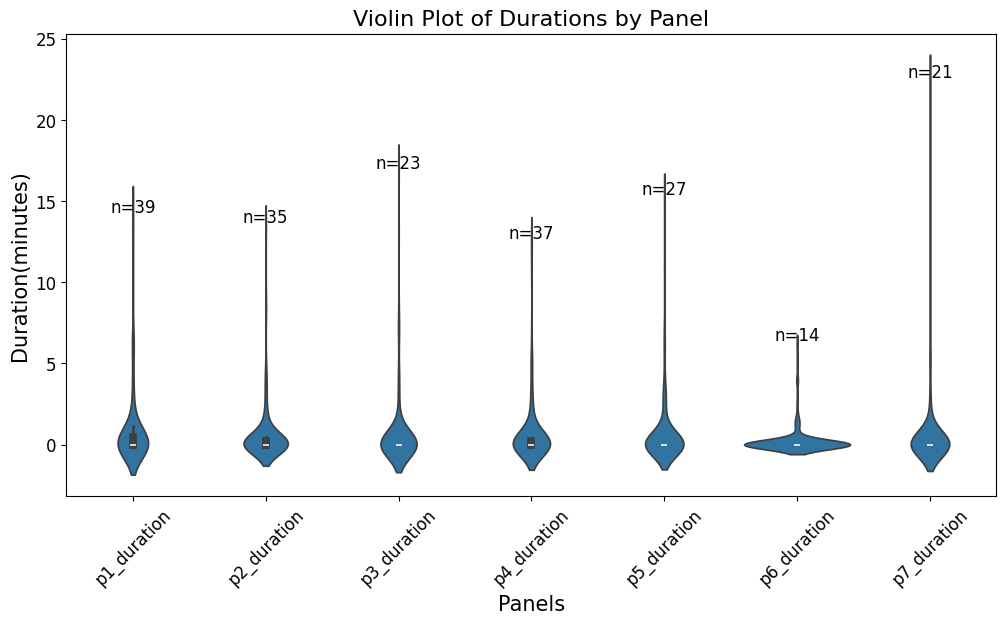

In [131]:
df = pd.DataFrame(eye_tracker_df)

df_melted = pd.melt(df, var_name='panel', value_name='duration')

df_melted['panel'] = df_melted['panel'].astype(str)
df_melted['duration'] = pd.to_numeric(df_melted['duration'], errors='coerce')
df_melted = df_melted.dropna(subset=['duration'])

panel_order = [
    "p1_duration", "p2_duration", "p3_duration", "p4_duration",
    "p5_duration", "p6_duration", "p7_duration"
]

plt.figure(figsize=(12, 6))
sns.violinplot(x='panel', y='duration', data=df_melted, order=panel_order)

for i, group in enumerate(panel_order):
    y = df_melted[(df_melted['panel'] == group) & (df_melted['duration'] != 0)]['duration']
    plt.text(x=i, y=max(y) if not y.empty else 0, s=f'n={len(y)}', ha='center', va='bottom', fontsize=12)

plt.xlabel('Panels', fontsize=15)
plt.ylabel('Duration(minutes)', fontsize=15)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.title('Violin Plot of Durations by Panel', fontsize=16)

plt.show()

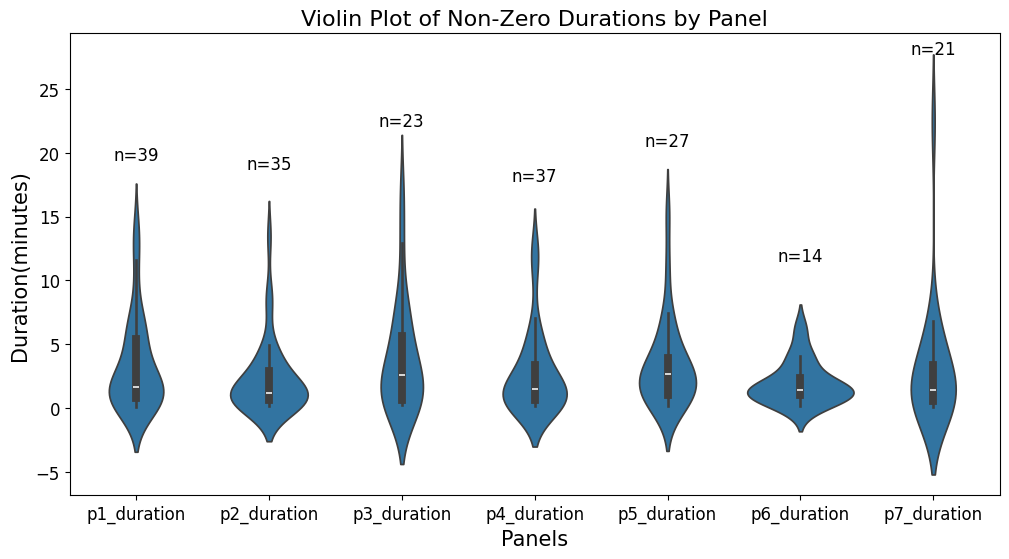

In [132]:

df = pd.DataFrame(eye_tracker_df)

df_melted = pd.melt(df, var_name='panel', value_name='duration')

df_melted['panel'] = df_melted['panel'].astype(str)

df_melted['duration'] = pd.to_numeric(df_melted['duration'], errors='coerce')
df_melted = df_melted.dropna(subset=['duration'])  # Drop NaN values
df_melted = df_melted[df_melted['duration'] != 0]  # Keep non-zero entries

panel_order = [
    "p1_duration", "p2_duration", "p3_duration", "p4_duration",
    "p5_duration", "p6_duration", "p7_duration"
]

plt.figure(figsize=(12, 6))
sns.violinplot(x='panel', y='duration', data=df_melted, order=panel_order)

for i, group in enumerate(panel_order):
    y = df_melted[df_melted['panel'] == group]['duration']
    plt.text(x=i, y=max(y) + 5, s=f'n={len(y)}', ha='center', va='bottom', fontsize=12)

plt.xlabel('Panels', fontsize=15)
plt.ylabel('Duration(minutes)', fontsize=15)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.title('Violin Plot of Non-Zero Durations by Panel', fontsize=16)

plt.show()


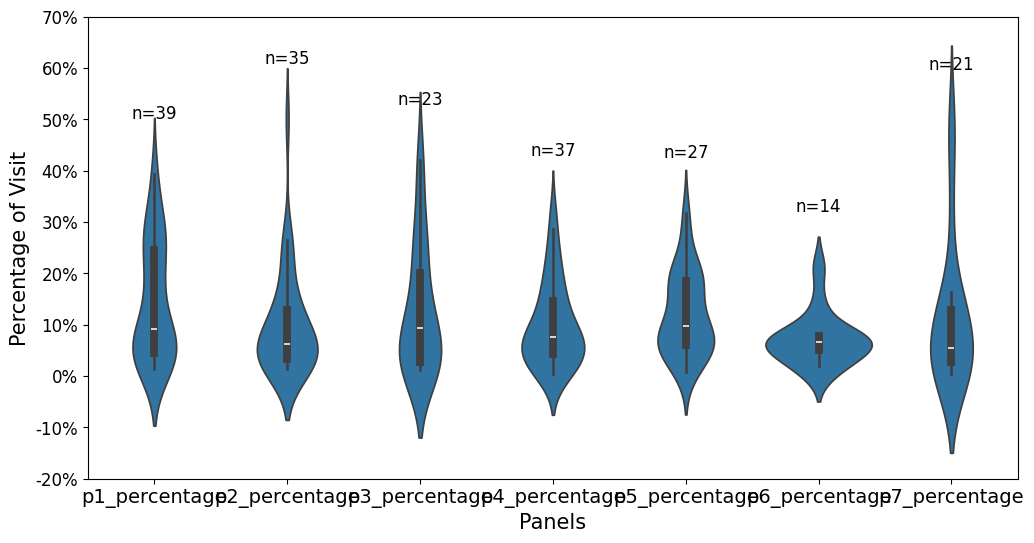

In [133]:

df = pd.DataFrame(eye_tracker_df)

df_melted = pd.melt(df, var_name='panel', value_name='percentage')

df_melted['panel'] = df_melted['panel'].astype(str)

df_melted['percentage'] = pd.to_numeric(df_melted['percentage'], errors='coerce')
df_melted = df_melted.dropna(subset=['percentage'])  # Drop NaN values
df_melted = df_melted[df_melted['percentage'] != 0]  # Keep non-zero entries

panel_order = [
    "p1_percentage", "p2_percentage", "p3_percentage", "p4_percentage",
    "p5_percentage", "p6_percentage", "p7_percentage"
]

plt.figure(figsize=(12, 6))
sns.violinplot(x='panel', y='percentage', data=df_melted, order=panel_order)

for i, group in enumerate(panel_order):
    y = df_melted[df_melted['panel'] == group]['percentage']
    plt.text(x=i, y=max(y) + 0.1, s=f'n={len(y)}', ha='center', va='bottom', fontsize=12)

plt.xlabel('Panels', fontsize=15)
plt.ylabel('Percentage of Visit', fontsize=15)
current_yticks = plt.yticks()[0]
plt.yticks(ticks=current_yticks, labels=[f'{int(tick*100)}%' for tick in current_yticks], fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [134]:
eye_tracker_df

,Start time,ID,Matter Emotions,Life Emotions,Thought Emotions,Matter Learning,Life Learning,Thought Learning,Admiration,Confusion,...,p6_percentage,p7_percentage,matter_panel_percentage,life_panel_percentage,thought_panel_percentage,overall_panel_percentage,interactive_panel_duration,noninteractive_panel_duration,interactive_panel_percentage,noninteractive_panel_percentage
0,2023-09-26 16:34:00,D03-P011,8.0,3.0,6.0,5.0,7.0,7.0,8,3,...,0.0,0.000000,0.000000,0.135205,0.000000,0.135205,0.816848,1.524076,0.047179,0.088026
1,2023-09-26 16:59:30,D03-P012,7.0,7.0,7.0,7.0,7.0,7.0,8,1,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2023-09-26 17:19:10,D05-P013,4.0,6.0,8.0,3.0,5.0,7.0,5,2,...,0.0,0.000000,0.000000,0.053891,0.000000,0.089199,0.603050,0.920437,0.035308,0.053891
3,2023-09-26 17:27:36,D05-P014,7.0,6.0,8.0,6.0,7.0,8.0,8,4,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2023-09-26 17:26:13,D03-P013,8.0,8.0,8.0,8.0,8.0,5.0,8,1,...,0.0,0.000000,0.039131,0.025188,0.000000,0.064319,0.000000,1.668494,0.000000,0.064319
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,2023-10-01 23:02:26,D03-P066,6.0,8.0,5.0,6.0,5.0,6.0,8,1,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
166,2023-10-01 23:15:33,D01-P063,6.0,8.0,7.0,6.0,8.0,7.0,7,4,...,0.0,0.027815,0.067148,0.000000,0.027815,0.094963,0.606730,1.464672,0.027815,0.067148
167,2023-10-01 23:17:45,D05-P050,5.0,5.0,8.0,3.0,3.0,8.0,5,6,...,0.0,0.000000,0.025910,0.000000,0.000000,0.025910,0.733121,0.000000,0.025910,0.000000
168,2023-10-01 23:44:36,D01-P064,8.0,8.0,8.0,8.0,8.0,8.0,8,3,...,0.0,0.032536,0.029944,0.000000,0.032536,0.172592,2.617844,0.549530,0.142647,0.029944


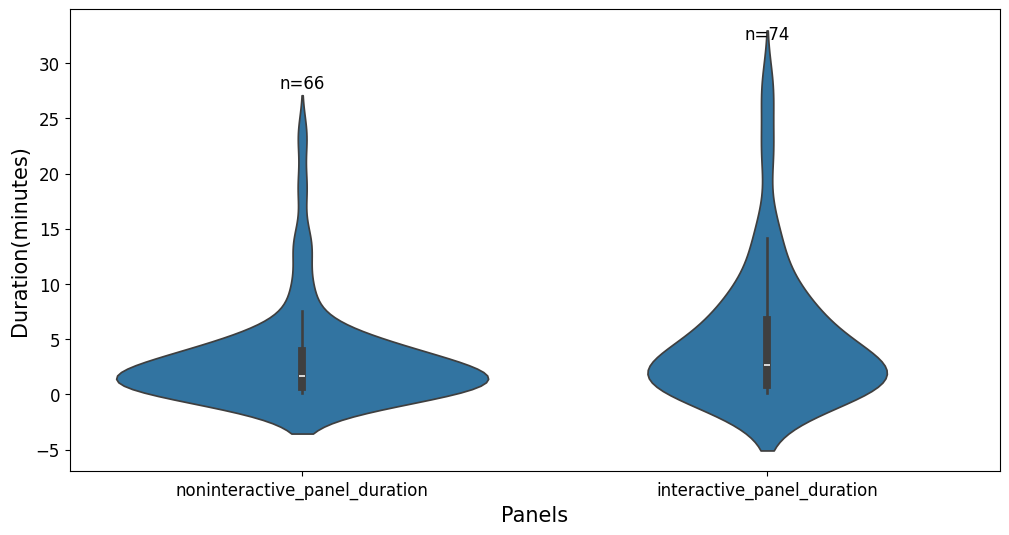

In [135]:

df = pd.DataFrame(eye_tracker_df)

df_melted = pd.melt(df, var_name='panel', value_name='duration')

df_melted['panel'] = df_melted['panel'].astype(str)

df_melted['duration'] = pd.to_numeric(df_melted['duration'], errors='coerce')
df_melted = df_melted.dropna(subset=['duration'])  # Drop NaN values
df_melted = df_melted[df_melted['duration'] != 0]  # Keep non-zero entries

panel_order = [ 'noninteractive_panel_duration' , 'interactive_panel_duration'
]

plt.figure(figsize=(12, 6))
sns.violinplot(x='panel', y='duration', data=df_melted, order=panel_order)

for i, group in enumerate(panel_order):
    y = df_melted[df_melted['panel'] == group]['duration']
    plt.text(x=i, y=max(y) +4, s=f'n={len(y)}', ha='center', va='bottom', fontsize=12)

plt.xlabel('Panels', fontsize=15)
plt.ylabel('Duration(minutes)', fontsize=15)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

plt.show()

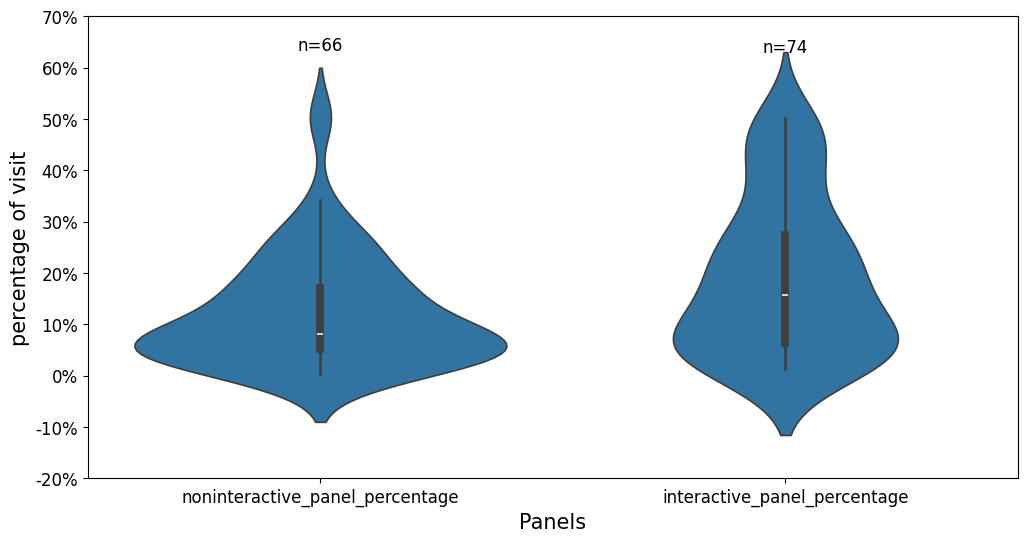

In [136]:

df = pd.DataFrame(eye_tracker_df)

df_melted = pd.melt(df, var_name='panel', value_name='percentage')

df_melted['panel'] = df_melted['panel'].astype(str)

df_melted['percentage'] = pd.to_numeric(df_melted['percentage'], errors='coerce')
df_melted = df_melted.dropna(subset=['percentage'])  # Drop NaN values
df_melted = df_melted[df_melted['percentage'] != 0]  # Keep non-zero entries

panel_order = [ 'noninteractive_panel_percentage' , 'interactive_panel_percentage'
]

plt.figure(figsize=(12, 6))
sns.violinplot(x='panel', y='percentage', data=df_melted, order=panel_order)

for i, group in enumerate(panel_order):
    y = df_melted[df_melted['panel'] == group]['percentage']
    plt.text(x=i, y=max(y)+0.12, s=f'n={len(y)}', ha='center', va='bottom', fontsize=12)

plt.xlabel('Panels', fontsize=15)
plt.ylabel('percentage of visit', fontsize=15)
plt.xticks(rotation=0, fontsize=12)
current_yticks = plt.yticks()[0]
plt.yticks(ticks=current_yticks, labels=[f'{int(tick*100)}%' for tick in current_yticks], fontsize=12)

plt.show()

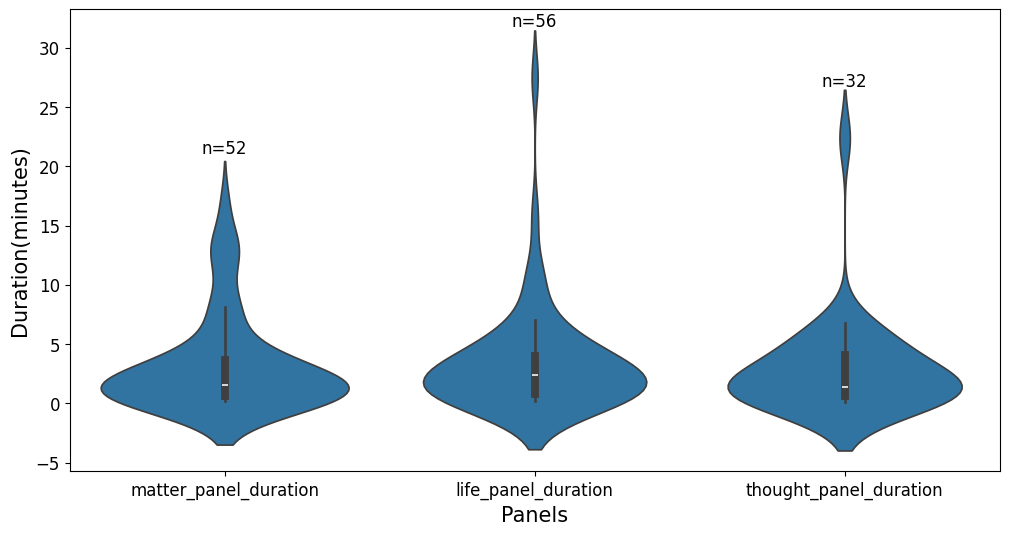

In [137]:
df = pd.DataFrame(eye_tracker_df)

df_melted = pd.melt(df, var_name='panel', value_name='duration')

df_melted['panel'] = df_melted['panel'].astype(str)

df_melted['duration'] = pd.to_numeric(df_melted['duration'], errors='coerce')
df_melted = df_melted.dropna(subset=['duration'])  # Drop NaN values
df_melted = df_melted[df_melted['duration'] != 0]  # Keep non-zero entries

panel_order = ['matter_panel_duration' , 'life_panel_duration', 'thought_panel_duration'
]

plt.figure(figsize=(12, 6))
sns.violinplot(x='panel', y='duration', data=df_melted, order=panel_order)

for i, group in enumerate(panel_order):
    y = df_melted[df_melted['panel'] == group]['duration']
    plt.text(x=i, y=max(y) +4, s=f'n={len(y)}', ha='center', va='bottom', fontsize=12)

plt.xlabel('Panels', fontsize=15)
plt.ylabel('Duration(minutes)', fontsize=15)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

plt.show()

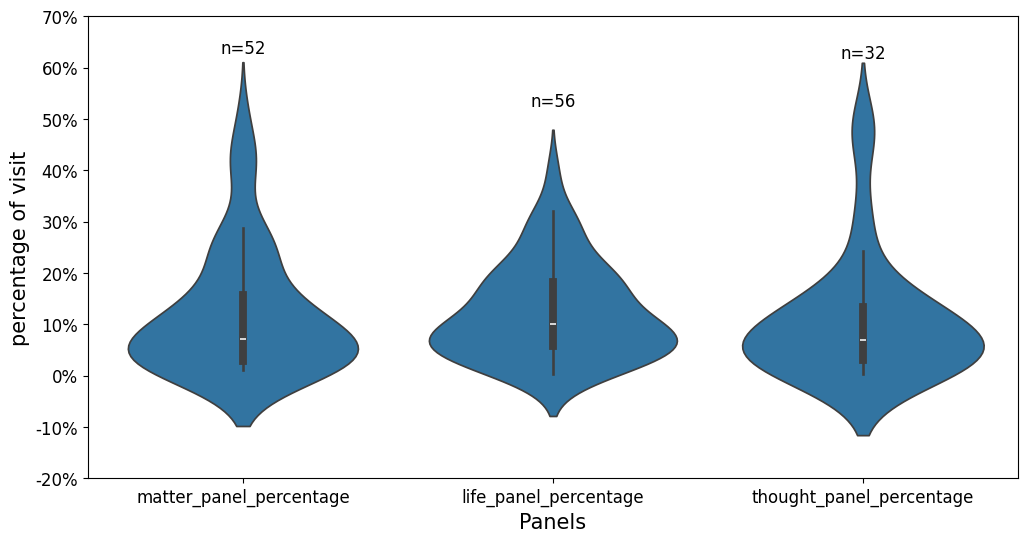

In [138]:

df = pd.DataFrame(eye_tracker_df)

df_melted = pd.melt(df, var_name='panel', value_name='percentage')

df_melted['panel'] = df_melted['panel'].astype(str)

df_melted['percentage'] = pd.to_numeric(df_melted['percentage'], errors='coerce')
df_melted = df_melted.dropna(subset=['percentage'])  # Drop NaN values
df_melted = df_melted[df_melted['percentage'] != 0]  # Keep non-zero entries

panel_order = ['matter_panel_percentage' , 'life_panel_percentage', 'thought_panel_percentage'
]

plt.figure(figsize=(12, 6))
sns.violinplot(x='panel', y='percentage', data=df_melted, order=panel_order)

for i, group in enumerate(panel_order):
    y = df_melted[df_melted['panel'] == group]['percentage']
    plt.text(x=i, y=max(y)+0.12, s=f'n={len(y)}', ha='center', va='bottom', fontsize=12)

plt.xlabel('Panels', fontsize=15)
plt.ylabel('percentage of visit', fontsize=15)
plt.xticks(rotation=0, fontsize=12)
current_yticks = plt.yticks()[0]
plt.yticks(ticks=current_yticks, labels=[f'{int(tick*100)}%' for tick in current_yticks], fontsize=12)

plt.show()

In [139]:
panel_columns = [f'p{i}_duration' for i in range(1, 8)]
total_time_per_panel = eye_tracker_df[panel_columns].sum()
total_time_per_panel


p1_duration    132.531568
p2_duration     80.425491
p3_duration     89.312981
p4_duration    100.791230
p5_duration     92.883401
p6_duration     27.811006
p7_duration     64.056550
dtype: float64

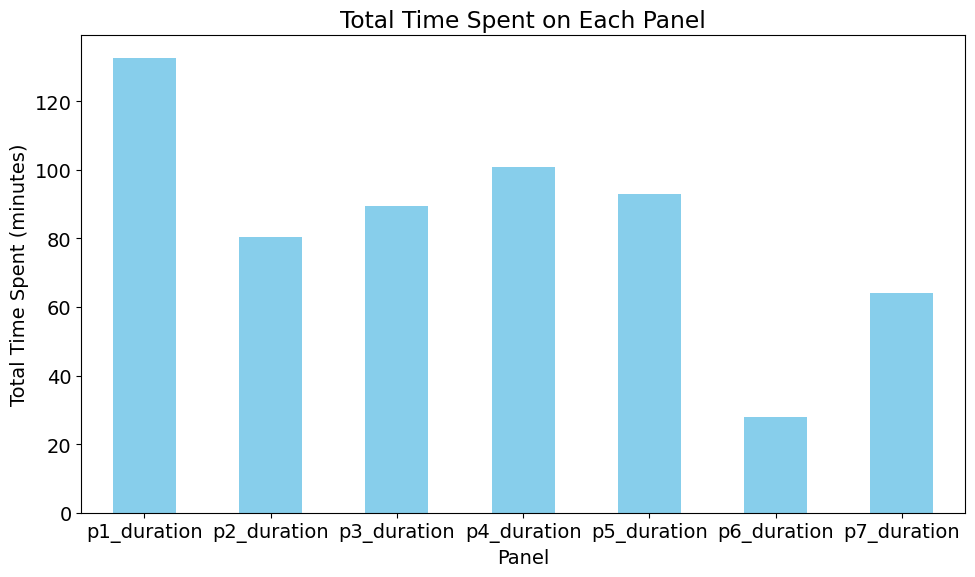

In [140]:
# Reorder the Series by the panel name (p1, p2, ..., p7)
# sorted_by_name = total_time_per_panel.sort_index()

# # Print the results to verify the order
# print("Total time spent on each panel (sorted by name):")
# print(sorted_by_name)

# Plot the bars
plt.figure(figsize=(10, 6))
total_time_per_panel.plot(kind='bar', color='skyblue')

plt.title('Total Time Spent on Each Panel')
plt.xlabel('Panel')
plt.ylabel('Total Time Spent (minutes)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [141]:
eye_tracking_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   recording id            170 non-null    object 
 1   ID                      170 non-null    object 
 2   has_corruption          170 non-null    bool   
 3   door_sequence           165 non-null    object 
 4   matter_duration         170 non-null    float64
 5   life_duration           170 non-null    float64
 6   thought_duration        170 non-null    float64
 7   p1_duration             170 non-null    float64
 8   p2_duration             170 non-null    float64
 9   p3_duration             170 non-null    float64
 10  p4_duration             170 non-null    float64
 11  p5_duration             170 non-null    float64
 12  p6_duration             170 non-null    float64
 13  p7_duration             170 non-null    float64
 14  phone_pickups           170 non-null    fl

# highlights from archive

In [142]:
eye_tracker_df['door_sequence'] = eye_tracker_df['door_sequence'].astype(str)

original_doors = sorted(set([door for seq in eye_tracker_df['door_sequence'] for door in seq.split(',')]))

desired_doors = ['cube1_entrance', 'cube1_entrance', 'cube1_exit', 'cube1_exit', 'cube2_entrance', 'cube2_entrance', 'cube2_exit', 'cube3_entrance', 'cube3_entrance', 'cube3_exit', 'cube3_exit']

flow_matrix = pd.DataFrame(0, index=original_doors, columns=original_doors)

for sequence in eye_tracker_df['door_sequence']:
    doors_visited = sequence.split(',')
    for i in range(len(doors_visited) - 1):
        flow_matrix.loc[doors_visited[i], doors_visited[i + 1]] += 1

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color='black', width=0.5),
        label=original_doors
    ),
    link=dict(
        arrowlen=15,
        source=[original_doors.index(src) for src in flow_matrix.index for _ in range(len(flow_matrix.columns))],
        target=[original_doors.index(dest) for _ in range(len(flow_matrix.index)) for dest in flow_matrix.columns],
        value=flow_matrix.values.flatten()
    )
)])

fig.update_traces(
    node=dict(label=desired_doors),
    selector=dict(type='sankey')
)

fig.write_html("sankey_plot.html")
plt.savefig(f"sankey_plot.jpg")

fig.show()


<Figure size 640x480 with 0 Axes>

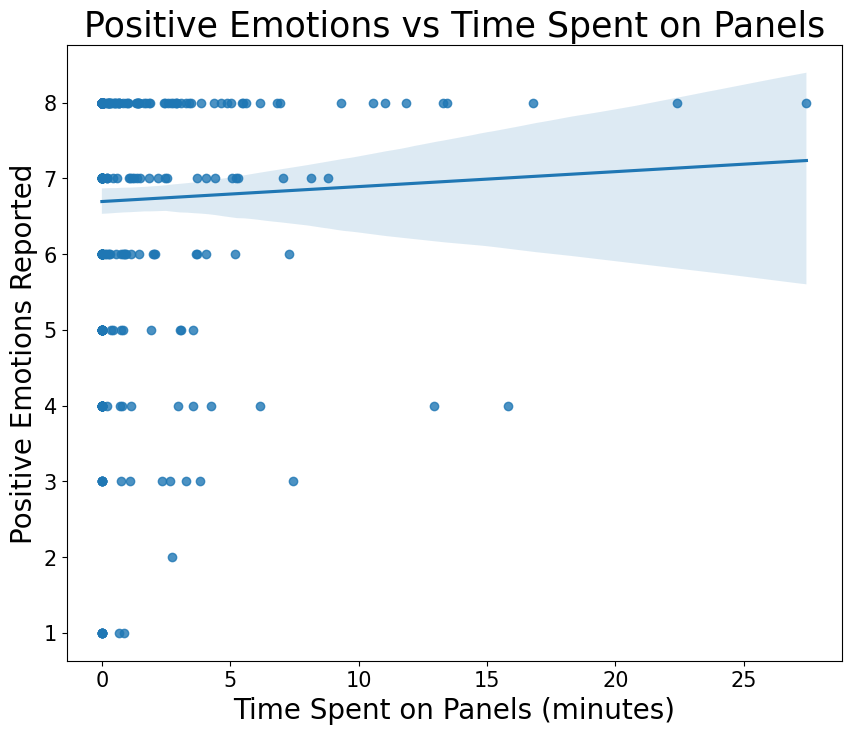

In [143]:
combined_df = pd.concat([eye_tracker_df[['matter_panel_duration', 'Matter Emotions']].rename(columns={'matter_panel_duration': 'duration', 'Matter Emotions': 'emotions'}),
                         eye_tracker_df[['life_panel_duration', 'Life Emotions']].rename(columns={'life_panel_duration': 'duration', 'Life Emotions': 'emotions'}),
                         eye_tracker_df[['thought_panel_duration', 'Thought Emotions']].rename(columns={'thought_panel_duration': 'duration', 'Thought Emotions': 'emotions'})],
                        ignore_index=True)

# Plot combined data with one regression line
plt.figure(figsize=(10, 8))
sns.regplot(x='duration', y='emotions', data=combined_df)
plt.title('Positive Emotions vs Time Spent on Panels', fontsize=25)
plt.xlabel('Time Spent on Panels (minutes)', fontsize=20)
plt.ylabel('Positive Emotions Reported', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

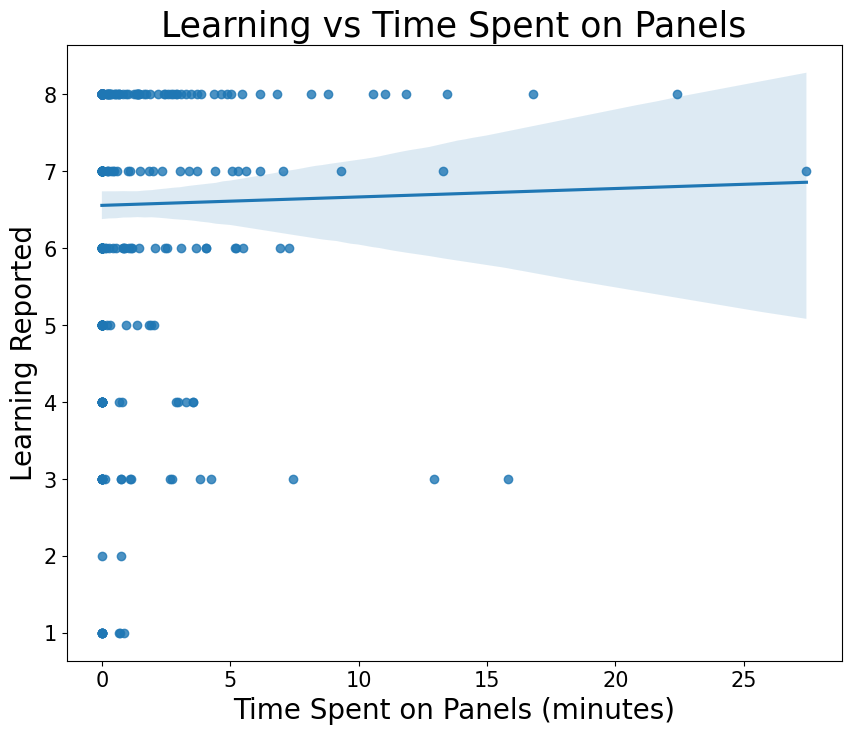

In [144]:
combined_df = pd.concat([eye_tracker_df[['matter_panel_duration', 'Matter Learning']].rename(columns={'matter_panel_duration': 'duration', 'Matter Learning': 'learning'}),
                         eye_tracker_df[['life_panel_duration', 'Life Learning']].rename(columns={'life_panel_duration': 'duration', 'Life Learning': 'learning'}),
                         eye_tracker_df[['thought_panel_duration', 'Thought Learning']].rename(columns={'thought_panel_duration': 'duration', 'Thought Learning': 'learning'})],
                        ignore_index=True)

# Plot combined data with one regression line
plt.figure(figsize=(10, 8))
sns.regplot(x='duration', y='learning', data=combined_df)
plt.title('Learning vs Time Spent on Panels', fontsize=25)
plt.xlabel('Time Spent on Panels (minutes)', fontsize=20)
plt.ylabel('Learning Reported', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()


# Who engages with panels more frequently? (more frequently ?= more pickups)
# Who are heavy users and who are low users?

# Do older people spend less time on panels? 

In [160]:
eye_tracker_df['Age group 2'] = eye_tracker_df['Age group'].apply(
    lambda x: 'Up to 30 years' if x in ['Até 18 anos', '19-30 anos'] else '31 years and above'
)

eye_tracker_df[['Age group', 'Age group 2']]


,Age group,Age group 2
0,31-59 anos,31 years and above
1,19-30 anos,Up to 30 years
2,31-59 anos,31 years and above
3,19-30 anos,Up to 30 years
4,31-59 anos,31 years and above
...,...,...
165,19-30 anos,Up to 30 years
166,19-30 anos,Up to 30 years
167,19-30 anos,Up to 30 years
168,19-30 anos,Up to 30 years


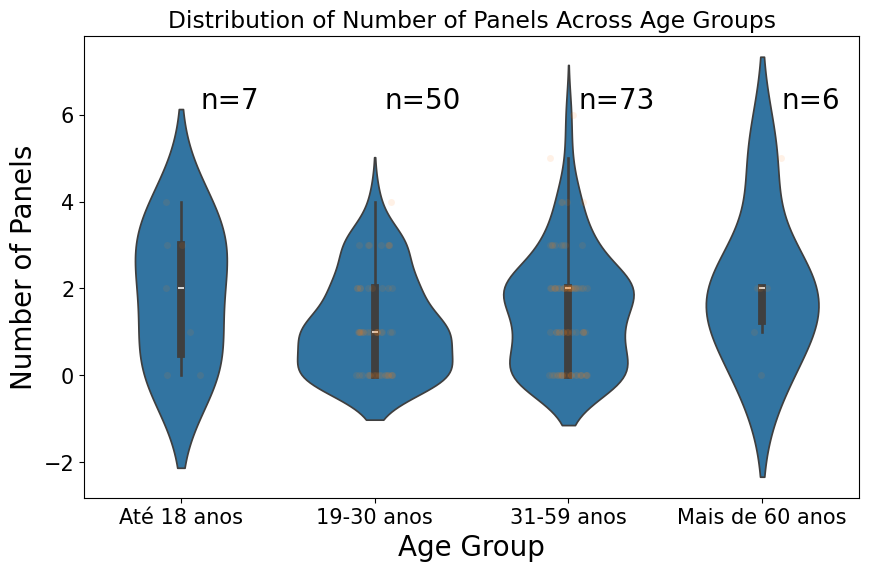

In [154]:
age_group_order = ['Até 18 anos', '19-30 anos', '31-59 anos', 'Mais de 60 anos']

plt.figure(figsize=(10, 6))

sns.violinplot(x='Age group', y='number_of_panels', data=eye_tracker_df, order=age_group_order)
sns.stripplot(x='Age group', y='number_of_panels', data=eye_tracker_df, order=age_group_order, dodge=True, jitter=True, alpha=0.1)

for i, group in enumerate(age_group_order):
    x = i
    y = eye_tracker_df[eye_tracker_df['Age group'] == group]['number_of_panels']
    plt.text(x + 0.25, 6, f'n={len(y)}', ha='center', va='bottom', fontsize=20)

plt.xlabel('Age Group', fontsize=20)
plt.ylabel('Number of Panels', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.title('Distribution of Number of Panels Across Age Groups')
plt.show()


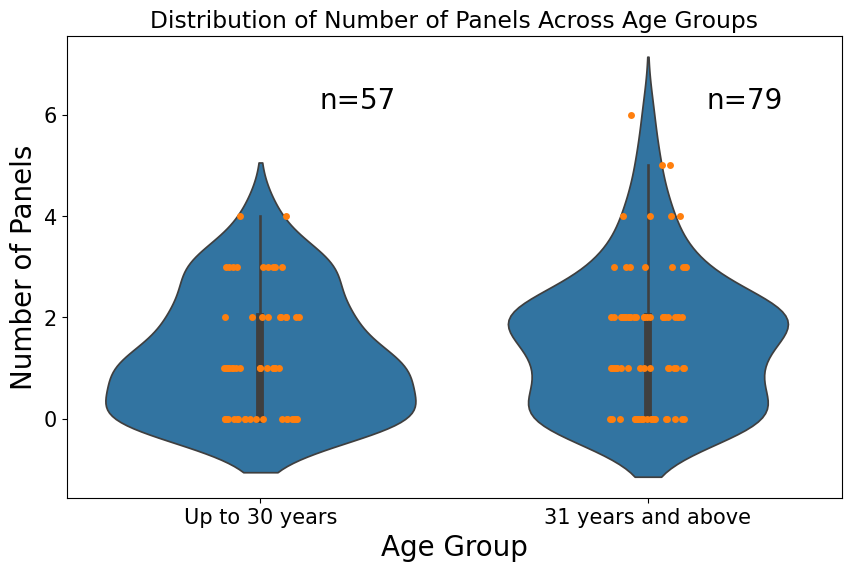

In [162]:
age_group_order = ['Up to 30 years', '31 years and above']

plt.figure(figsize=(10, 6))

sns.violinplot(x='Age group 2', y='number_of_panels', data=eye_tracker_df, order=age_group_order)
sns.stripplot(x='Age group 2', y='number_of_panels', data=eye_tracker_df, order=age_group_order, dodge=True, jitter=True, alpha=1)

for i, group in enumerate(age_group_order):
    x = i
    y = eye_tracker_df[eye_tracker_df['Age group 2'] == group]['number_of_panels']
    plt.text(x + 0.25, 6, f'n={len(y)}', ha='center', va='bottom', fontsize=20)

plt.xlabel('Age Group', fontsize=20)
plt.ylabel('Number of Panels', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.title('Distribution of Number of Panels Across Age Groups')
plt.show()


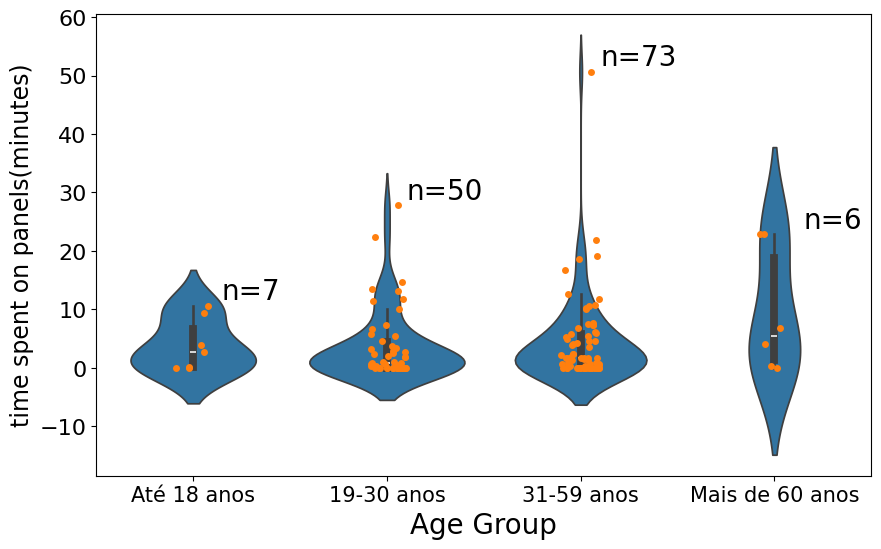

In [169]:
age_group_order = ['Até 18 anos', '19-30 anos', '31-59 anos', 'Mais de 60 anos']

plt.figure(figsize=(10, 6))

sns.violinplot(x='Age group', y='overall_panel_duration', data=eye_tracker_df, order=age_group_order)
sns.stripplot(x='Age group', y='overall_panel_duration', data=eye_tracker_df, order=age_group_order, dodge=True, jitter=True)

for i, group in enumerate(age_group_order):
    x = i
    y = eye_tracker_df[eye_tracker_df['Age group'] == group]['overall_panel_duration']
    plt.text(x + 0.3, max(y), f'n={len(y)}', ha='center', va='bottom', fontsize=20)

plt.xlabel('Age Group', fontsize=20)
plt.ylabel( 'time spent on panels(minutes)', fontsize=17)
plt.xticks(fontsize=15)
current_yticks = plt.yticks()[0]
plt.yticks(fontsize=16)

plt.show()


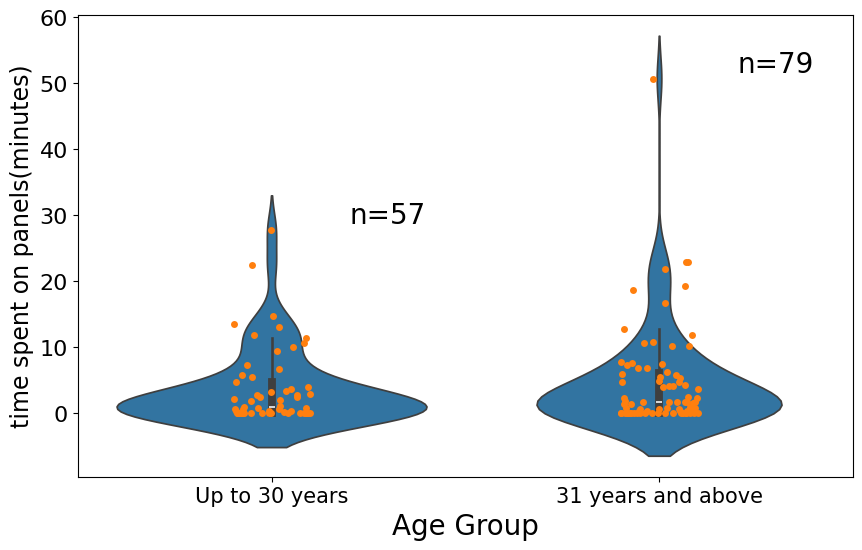

In [170]:
age_group_order = ['Up to 30 years', '31 years and above']

plt.figure(figsize=(10, 6))

sns.violinplot(x='Age group 2', y='overall_panel_duration', data=eye_tracker_df, order=age_group_order)
sns.stripplot(x='Age group 2', y='overall_panel_duration', data=eye_tracker_df, order=age_group_order, dodge=True, jitter=True)

for i, group in enumerate(age_group_order):
    x = i
    y = eye_tracker_df[eye_tracker_df['Age group 2'] == group]['overall_panel_duration']
    plt.text(x + 0.3, max(y), f'n={len(y)}', ha='center', va='bottom', fontsize=20)

plt.xlabel('Age Group', fontsize=20)
plt.ylabel( 'time spent on panels(minutes)', fontsize=17)
plt.xticks(fontsize=15)
current_yticks = plt.yticks()[0]
plt.yticks(fontsize=16)

plt.show()


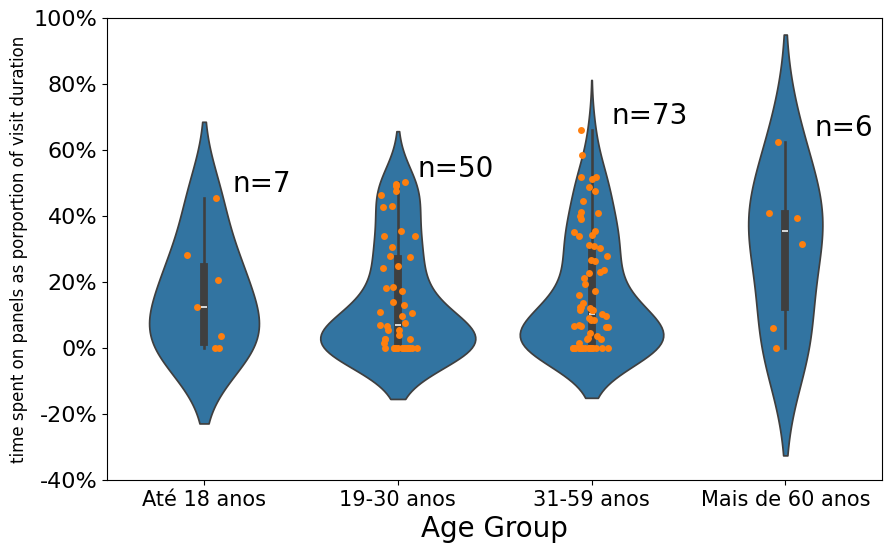

In [171]:
age_group_order = ['Até 18 anos', '19-30 anos', '31-59 anos', 'Mais de 60 anos']

plt.figure(figsize=(10, 6))

sns.violinplot(x='Age group', y='overall_panel_percentage', data=eye_tracker_df, order=age_group_order)
sns.stripplot(x='Age group', y='overall_panel_percentage', data=eye_tracker_df, order=age_group_order, dodge=True, jitter=True)

for i, group in enumerate(age_group_order):
    x = i
    y = eye_tracker_df[eye_tracker_df['Age group'] == group]['overall_panel_percentage']
    plt.text(x + 0.3, max(y), f'n={len(y)}', ha='center', va='bottom', fontsize=20)

plt.xlabel('Age Group', fontsize=20)
plt.ylabel( 'time spent on panels as porportion of visit duration', fontsize=12)
plt.ylim([-0.25, 1])
plt.xticks(fontsize=15)
current_yticks = plt.yticks()[0]
plt.yticks(ticks=current_yticks, labels=[f'{int(tick*100)}%' for tick in current_yticks], fontsize=16)

plt.show()


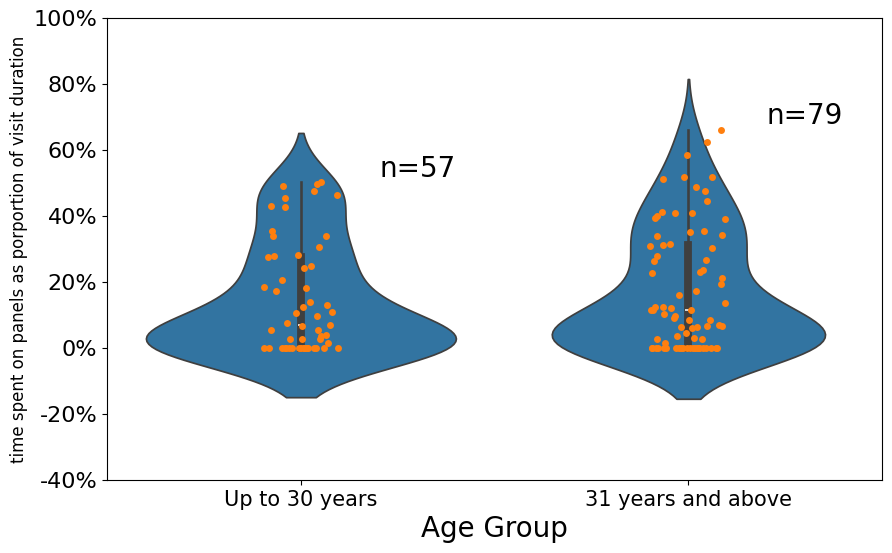

In [172]:
age_group_order = ['Up to 30 years', '31 years and above']

plt.figure(figsize=(10, 6))

sns.violinplot(x='Age group 2', y='overall_panel_percentage', data=eye_tracker_df, order=age_group_order)
sns.stripplot(x='Age group 2', y='overall_panel_percentage', data=eye_tracker_df, order=age_group_order, dodge=True, jitter=True)

for i, group in enumerate(age_group_order):
    x = i
    y = eye_tracker_df[eye_tracker_df['Age group 2'] == group]['overall_panel_percentage']
    plt.text(x + 0.3, max(y), f'n={len(y)}', ha='center', va='bottom', fontsize=20)

plt.xlabel('Age Group', fontsize=20)
plt.ylabel( 'time spent on panels as porportion of visit duration', fontsize=12)
plt.ylim([-0.25, 1])
plt.xticks(fontsize=15)
current_yticks = plt.yticks()[0]
plt.yticks(ticks=current_yticks, labels=[f'{int(tick*100)}%' for tick in current_yticks], fontsize=16)

plt.show()


# (numer of people in each age group who engaged in interacting with panels) / (number of people in that age group)

In [148]:
# code for plot 

Check the same things across: 
1) First visitors vs. on first visitors
2) how many accompanies?
3) Gender
4) local vs. tourist


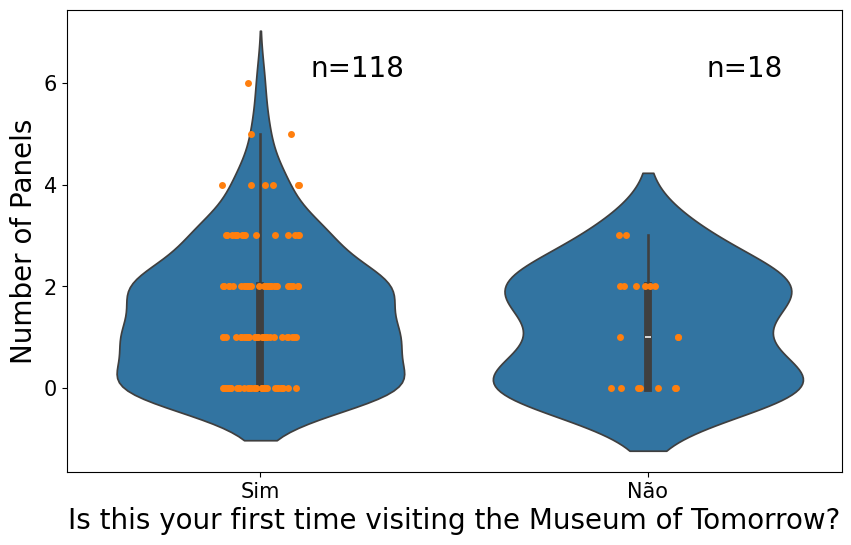

In [179]:
answer_order = ['Sim', 'Não']

plt.figure(figsize=(10, 6))

sns.violinplot(x='Is this your first time visiting the Museum of Tomorrow?', y='number_of_panels', data=eye_tracker_df, order=answer_order)
sns.stripplot(x='Is this your first time visiting the Museum of Tomorrow?', y='number_of_panels', data=eye_tracker_df, order=answer_order, dodge=True, jitter=True, alpha=1)

for i, group in enumerate(answer_order):
    x = i
    y = eye_tracker_df[eye_tracker_df['Is this your first time visiting the Museum of Tomorrow?'] == group]['number_of_panels']
    plt.text(x + 0.25, 6, f'n={len(y)}', ha='center', va='bottom', fontsize=20)

plt.xlabel('Is this your first time visiting the Museum of Tomorrow?', fontsize=20)
plt.ylabel('Number of Panels', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

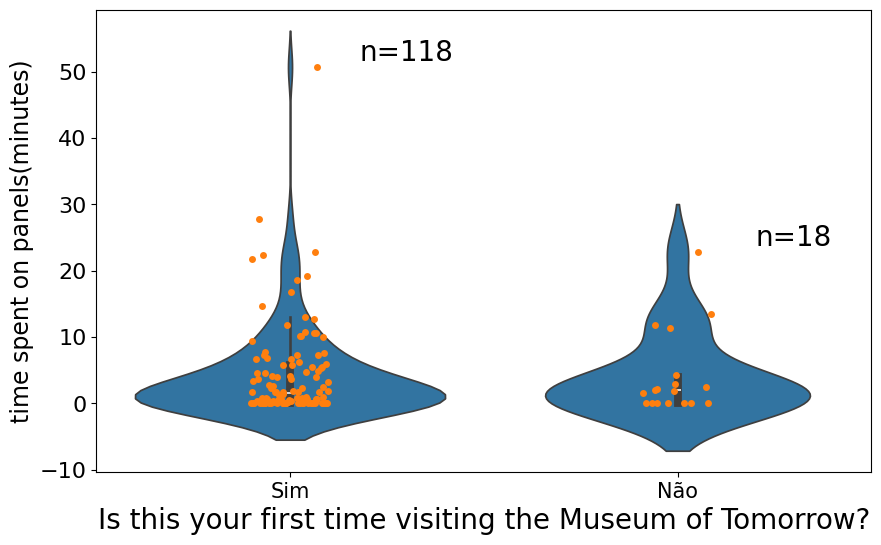

In [180]:
answer_order = ['Sim', 'Não']
plt.figure(figsize=(10, 6))

sns.violinplot(x='Is this your first time visiting the Museum of Tomorrow?', y='overall_panel_duration', data=eye_tracker_df, order=answer_order)
sns.stripplot(x='Is this your first time visiting the Museum of Tomorrow?', y='overall_panel_duration', data=eye_tracker_df, order=answer_order, dodge=True, jitter=True)

for i, group in enumerate(answer_order):
    x = i
    y = eye_tracker_df[eye_tracker_df['Is this your first time visiting the Museum of Tomorrow?'] == group]['overall_panel_duration']
    plt.text(x + 0.3, max(y), f'n={len(y)}', ha='center', va='bottom', fontsize=20)

plt.xlabel('Is this your first time visiting the Museum of Tomorrow?', fontsize=20)
plt.ylabel( 'time spent on panels(minutes)', fontsize=17)
plt.xticks(fontsize=15)
current_yticks = plt.yticks()[0]
plt.yticks(fontsize=16)

plt.show()


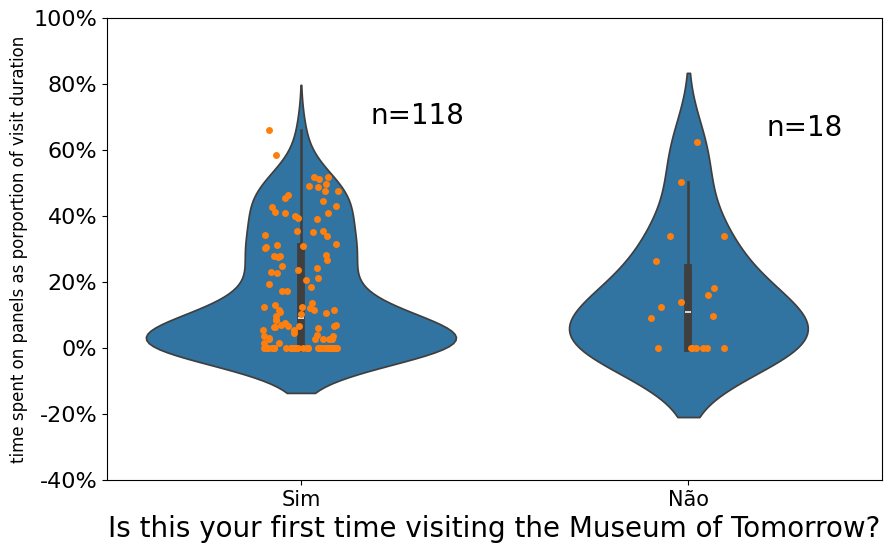

In [181]:
answer_order = ['Sim', 'Não']
plt.figure(figsize=(10, 6))

sns.violinplot(x='Is this your first time visiting the Museum of Tomorrow?', y='overall_panel_percentage', data=eye_tracker_df, order=answer_order)
sns.stripplot(x='Is this your first time visiting the Museum of Tomorrow?', y='overall_panel_percentage', data=eye_tracker_df, order=answer_order, dodge=True, jitter=True)

for i, group in enumerate(answer_order):
    x = i
    y = eye_tracker_df[eye_tracker_df['Is this your first time visiting the Museum of Tomorrow?'] == group]['overall_panel_percentage']
    plt.text(x + 0.3, max(y), f'n={len(y)}', ha='center', va='bottom', fontsize=20)

plt.xlabel('Is this your first time visiting the Museum of Tomorrow?', fontsize=20)
plt.ylabel( 'time spent on panels as porportion of visit duration', fontsize=12)
plt.ylim([-0.25, 1])
plt.xticks(fontsize=15)
current_yticks = plt.yticks()[0]
plt.yticks(ticks=current_yticks, labels=[f'{int(tick*100)}%' for tick in current_yticks], fontsize=16)

plt.show()


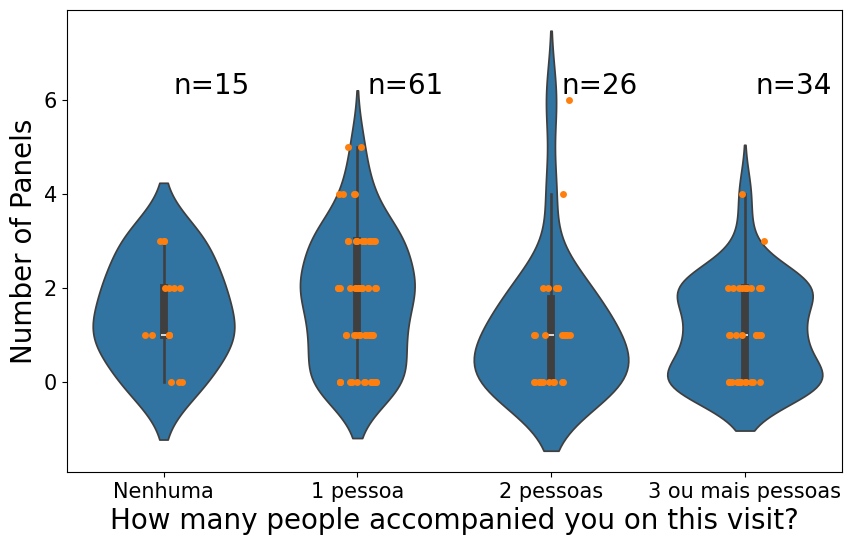

In [185]:
answer_order = ['Nenhuma','1 pessoa', '2 pessoas', '3 ou mais pessoas']

plt.figure(figsize=(10, 6))

sns.violinplot(x='How many people accompanied you on this visit?', y='number_of_panels', data=eye_tracker_df, order=answer_order)
sns.stripplot(x='How many people accompanied you on this visit?', y='number_of_panels', data=eye_tracker_df, order=answer_order, dodge=True, jitter=True, alpha=1)

for i, group in enumerate(answer_order):
    x = i
    y = eye_tracker_df[eye_tracker_df['How many people accompanied you on this visit?'] == group]['number_of_panels']
    plt.text(x + 0.25, 6, f'n={len(y)}', ha='center', va='bottom', fontsize=20)

plt.xlabel('How many people accompanied you on this visit?', fontsize=20)
plt.ylabel('Number of Panels', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

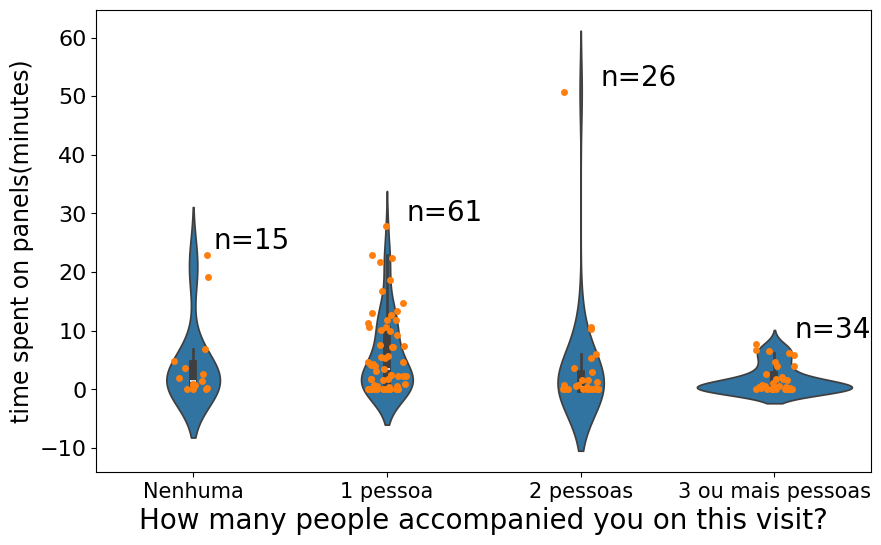

In [186]:
answer_order = ['Nenhuma','1 pessoa', '2 pessoas', '3 ou mais pessoas']
plt.figure(figsize=(10, 6))

sns.violinplot(x='How many people accompanied you on this visit?', y='overall_panel_duration', data=eye_tracker_df, order=answer_order)
sns.stripplot(x='How many people accompanied you on this visit?', y='overall_panel_duration', data=eye_tracker_df, order=answer_order, dodge=True, jitter=True)

for i, group in enumerate(answer_order):
    x = i
    y = eye_tracker_df[eye_tracker_df['How many people accompanied you on this visit?'] == group]['overall_panel_duration']
    plt.text(x + 0.3, max(y), f'n={len(y)}', ha='center', va='bottom', fontsize=20)

plt.xlabel('How many people accompanied you on this visit?', fontsize=20)
plt.ylabel( 'time spent on panels(minutes)', fontsize=17)
plt.xticks(fontsize=15)
current_yticks = plt.yticks()[0]
plt.yticks(fontsize=16)

plt.show()


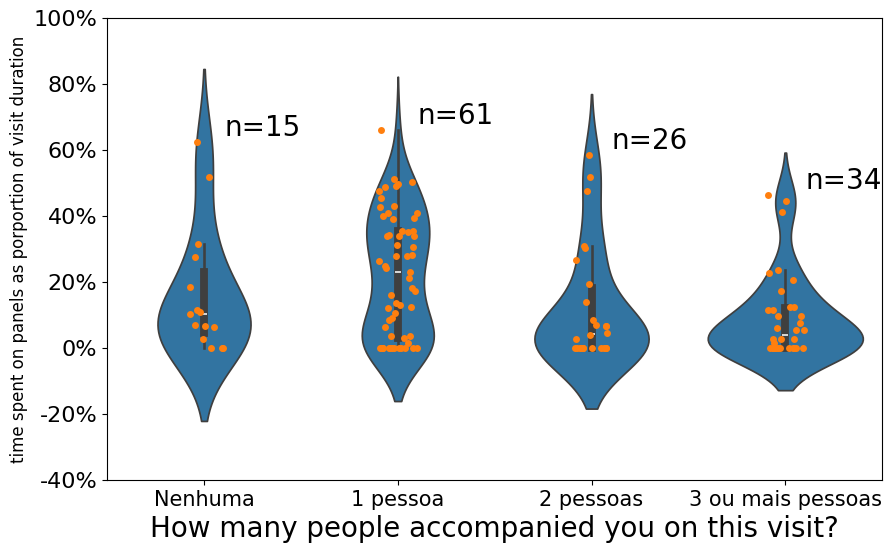

In [187]:
answer_order = ['Nenhuma','1 pessoa', '2 pessoas', '3 ou mais pessoas']
plt.figure(figsize=(10, 6))

sns.violinplot(x='How many people accompanied you on this visit?', y='overall_panel_percentage', data=eye_tracker_df, order=answer_order)
sns.stripplot(x='How many people accompanied you on this visit?', y='overall_panel_percentage', data=eye_tracker_df, order=answer_order, dodge=True, jitter=True)

for i, group in enumerate(answer_order):
    x = i
    y = eye_tracker_df[eye_tracker_df['How many people accompanied you on this visit?'] == group]['overall_panel_percentage']
    plt.text(x + 0.3, max(y), f'n={len(y)}', ha='center', va='bottom', fontsize=20)

plt.xlabel('How many people accompanied you on this visit?', fontsize=20)
plt.ylabel( 'time spent on panels as porportion of visit duration', fontsize=12)
plt.ylim([-0.25, 1])
plt.xticks(fontsize=15)
current_yticks = plt.yticks()[0]
plt.yticks(ticks=current_yticks, labels=[f'{int(tick*100)}%' for tick in current_yticks], fontsize=16)

plt.show()


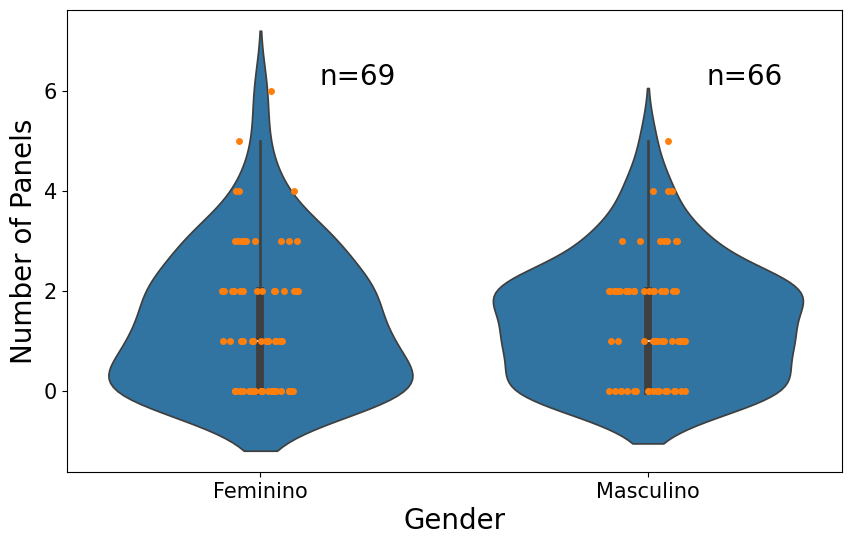

In [194]:
answer_order = ['Feminino','Masculino']
plt.figure(figsize=(10, 6))

sns.violinplot(x='Gender', y='number_of_panels', data=eye_tracker_df, order=answer_order)
sns.stripplot(x='Gender', y='number_of_panels', data=eye_tracker_df, order=answer_order, dodge=True, jitter=True, alpha=1)

for i, group in enumerate(answer_order):
    x = i
    y = eye_tracker_df[eye_tracker_df['Gender'] == group]['number_of_panels']
    plt.text(x + 0.25, 6, f'n={len(y)}', ha='center', va='bottom', fontsize=20)

plt.xlabel('Gender', fontsize=20)
plt.ylabel('Number of Panels', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

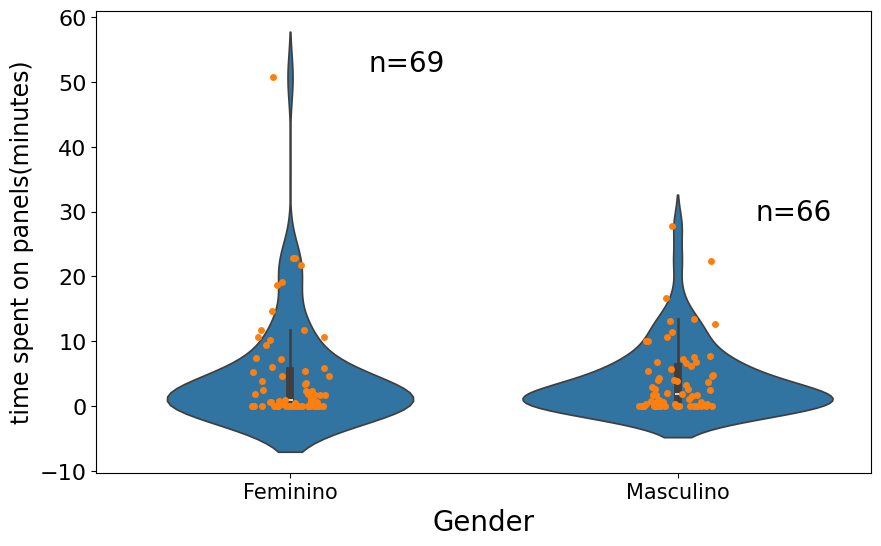

In [195]:
answer_order = ['Feminino','Masculino']
plt.figure(figsize=(10, 6))

sns.violinplot(x='Gender', y='overall_panel_duration', data=eye_tracker_df, order=answer_order)
sns.stripplot(x='Gender', y='overall_panel_duration', data=eye_tracker_df, order=answer_order, dodge=True, jitter=True)

for i, group in enumerate(answer_order):
    x = i
    y = eye_tracker_df[eye_tracker_df['Gender'] == group]['overall_panel_duration']
    plt.text(x + 0.3, max(y), f'n={len(y)}', ha='center', va='bottom', fontsize=20)

plt.xlabel('Gender', fontsize=20)
plt.ylabel( 'time spent on panels(minutes)', fontsize=17)
plt.xticks(fontsize=15)
current_yticks = plt.yticks()[0]
plt.yticks(fontsize=16)

plt.show()


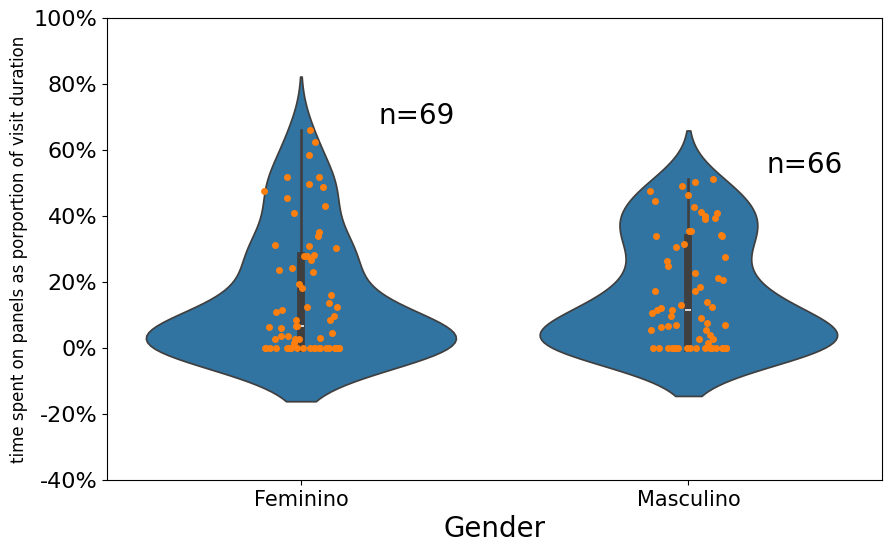

In [196]:
answer_order = ['Feminino','Masculino']
plt.figure(figsize=(10, 6))

sns.violinplot(x='Gender', y='overall_panel_percentage', data=eye_tracker_df, order=answer_order)
sns.stripplot(x='Gender', y='overall_panel_percentage', data=eye_tracker_df, order=answer_order, dodge=True, jitter=True)

for i, group in enumerate(answer_order):
    x = i
    y = eye_tracker_df[eye_tracker_df['Gender'] == group]['overall_panel_percentage']
    plt.text(x + 0.3, max(y), f'n={len(y)}', ha='center', va='bottom', fontsize=20)

plt.xlabel('Gender', fontsize=20)
plt.ylabel( 'time spent on panels as porportion of visit duration', fontsize=12)
plt.ylim([-0.25, 1])
plt.xticks(fontsize=15)
current_yticks = plt.yticks()[0]
plt.yticks(ticks=current_yticks, labels=[f'{int(tick*100)}%' for tick in current_yticks], fontsize=16)

plt.show()


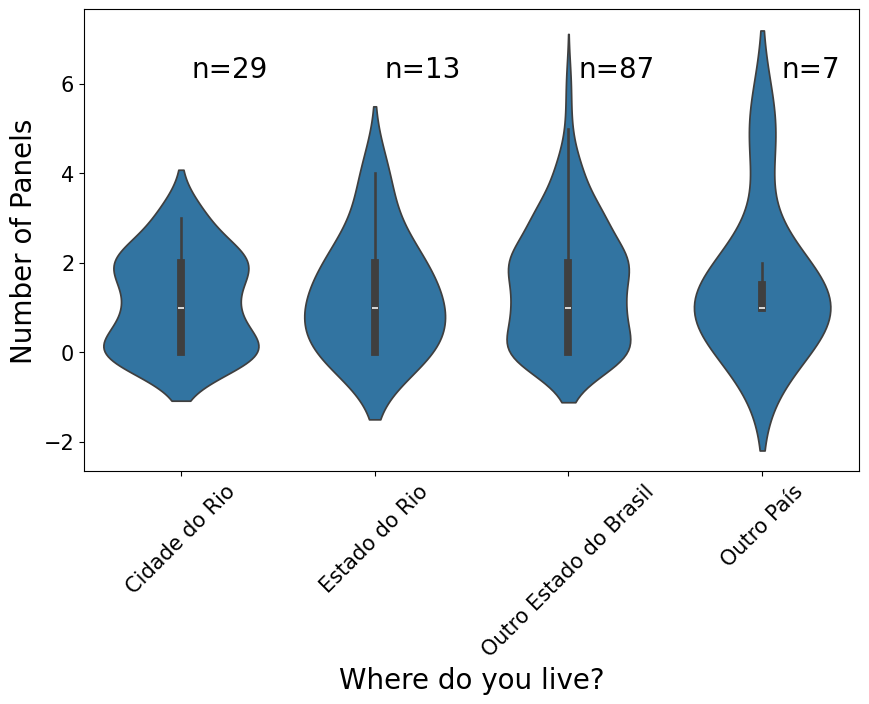

In [212]:
answer_order = ['Cidade do Rio','Estado do Rio','Outro Estado do Brasil','Outro País']
plt.figure(figsize=(10, 6))

sns.violinplot(x='Where do you live?', y='number_of_panels', data=eye_tracker_df, order=answer_order)
sns.stripplot(x='Where do you live?', y='number_of_panels', data=eye_tracker_df, order=answer_order, dodge=True, jitter=True, alpha=0)

for i, group in enumerate(answer_order):
    x = i
    y = eye_tracker_df[eye_tracker_df['Where do you live?'] == group]['number_of_panels']
    plt.text(x + 0.25, 6, f'n={len(y)}', ha='center', va='bottom', fontsize=20)

plt.xlabel('Where do you live?', fontsize=20)
plt.ylabel('Number of Panels', fontsize=20)
plt.xticks(fontsize=15, rotation=45)
plt.yticks(fontsize=15)
plt.show()

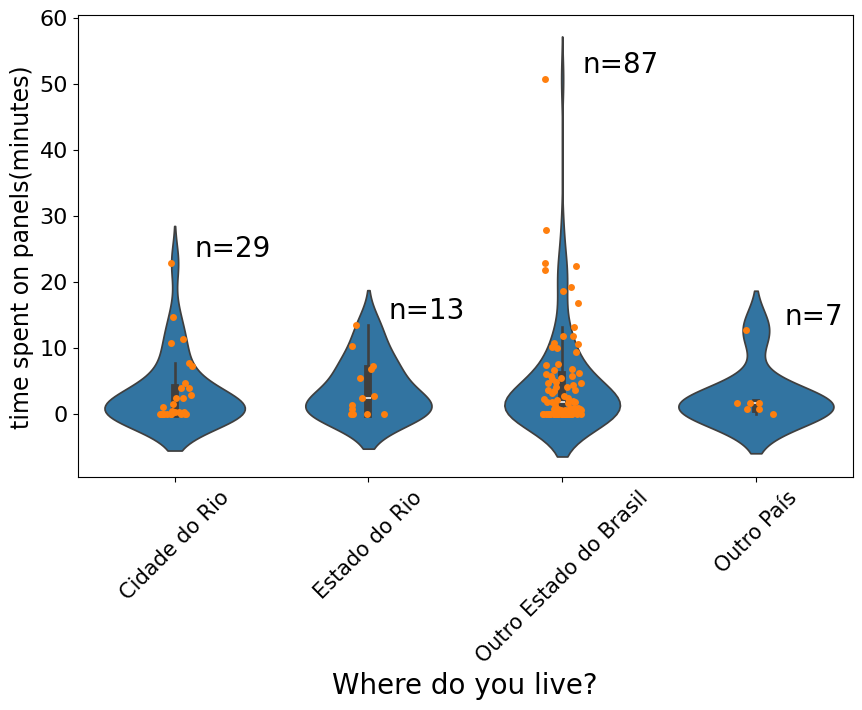

In [207]:
answer_order = ['Cidade do Rio','Estado do Rio','Outro Estado do Brasil','Outro País']
plt.figure(figsize=(10, 6))

sns.violinplot(x='Where do you live?', y='overall_panel_duration', data=eye_tracker_df, order=answer_order)
sns.stripplot(x='Where do you live?', y='overall_panel_duration', data=eye_tracker_df, order=answer_order, dodge=True, jitter=True)

for i, group in enumerate(answer_order):
    x = i
    y = eye_tracker_df[eye_tracker_df['Where do you live?'] == group]['overall_panel_duration']
    plt.text(x + 0.3, max(y), f'n={len(y)}', ha='center', va='bottom', fontsize=20)

plt.xlabel('Where do you live?', fontsize=20)
plt.ylabel( 'time spent on panels(minutes)', fontsize=17)
plt.xticks(fontsize=15, rotation=45)
current_yticks = plt.yticks()[0]
plt.yticks(fontsize=16)

plt.show()


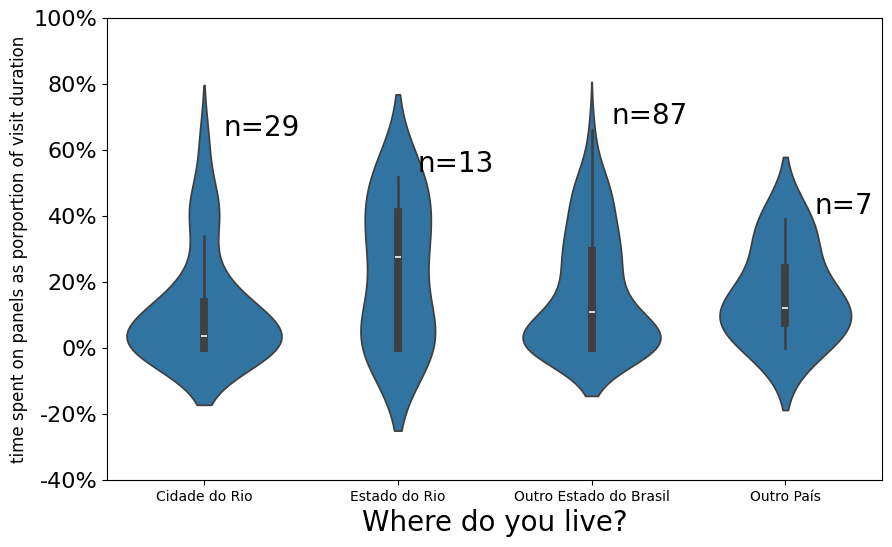

In [211]:
answer_order = ['Cidade do Rio','Estado do Rio','Outro Estado do Brasil','Outro País']
plt.figure(figsize=(10, 6))

sns.violinplot(x='Where do you live?', y='overall_panel_percentage', data=eye_tracker_df, order=answer_order)
sns.stripplot(x='Where do you live?', y='overall_panel_percentage', data=eye_tracker_df, order=answer_order, dodge=True, jitter=True, alpha=0)

for i, group in enumerate(answer_order):
    x = i
    y = eye_tracker_df[eye_tracker_df['Where do you live?'] == group]['overall_panel_percentage']
    plt.text(x + 0.3, max(y), f'n={len(y)}', ha='center', va='bottom', fontsize=20)

plt.xlabel('Where do you live?', fontsize=20)
plt.ylabel( 'time spent on panels as porportion of visit duration', fontsize=12)
plt.ylim([-0.25, 1])
plt.xticks(fontsize=10)
current_yticks = plt.yticks()[0]
plt.yticks(ticks=current_yticks, labels=[f'{int(tick*100)}%' for tick in current_yticks], fontsize=16)

plt.show()


In [209]:
eye_tracker_df['Where do you live?'].unique()

array(['Outro Estado do Brasil', 'Cidade do Rio', 'Outro País',
       'Estado do Rio'], dtype=object)

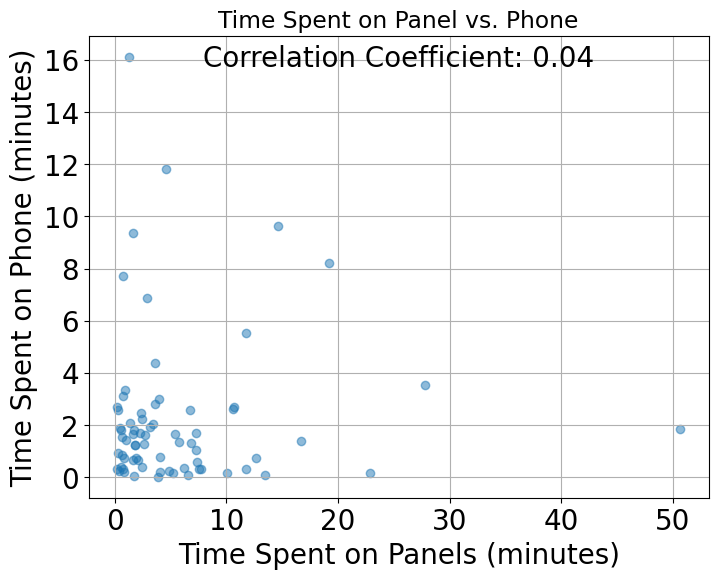

In [149]:
et_df_copy = eye_tracker_df
# et_df_copy = et_df_copy[et_df_copy['has_corruption'] == False]
# et_df_copy['overall_panel_duration_minutes'] = et_df_copy['overall_panel_duration'].dt.total_seconds() / 60
# et_df_copy['phone_duration_minutes'] = et_df_copy['phone_duration'].dt.total_seconds() / 60

et_df_copy = et_df_copy[(et_df_copy['overall_panel_duration'] != 0) & (et_df_copy['phone_duration'] != 0)]

plt.figure(figsize=(8, 6))
plt.scatter(et_df_copy['overall_panel_duration'], et_df_copy['phone_duration'], alpha=0.5)
plt.title('Time Spent on Panel vs. Phone')
plt.xlabel('Time Spent on Panels (minutes)', fontsize = 20)
plt.ylabel('Time Spent on Phone (minutes)', fontsize = 20)

correlation_coefficient = np.corrcoef(et_df_copy['overall_panel_duration'], et_df_copy['phone_duration'])[0, 1]

plt.text(0.5, 0.95, f'Correlation Coefficient: {correlation_coefficient:.2f}', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=20)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True)
plt.show()

C:\Users\aslan\AppData\Local\Temp\ipykernel_10960\3364009872.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\aslan\AppData\Local\Temp\ipykernel_10960\3364009872.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



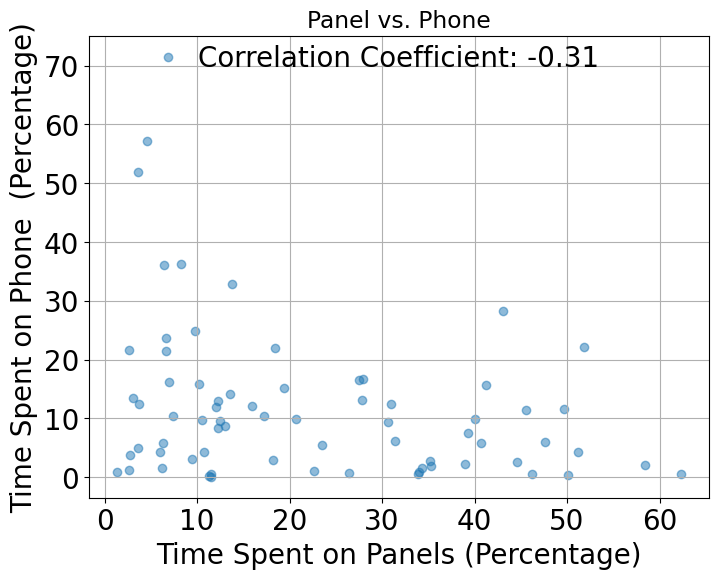

In [150]:
et_df_copy = eye_tracker_df

et_df_copy = et_df_copy[(et_df_copy['overall_panel_duration'] != 0) & (et_df_copy['phone_duration'] != 0)]

et_df_copy['phone_duration_percentage'] = (et_df_copy['phone_duration'] / et_df_copy['overall_duration']) * 100
et_df_copy['overall_panel_duration_minutes_percentage'] = (et_df_copy['overall_panel_duration'] / et_df_copy['overall_duration']) * 100

plt.figure(figsize=(8, 6))
plt.scatter(et_df_copy['overall_panel_duration_minutes_percentage'], et_df_copy['phone_duration_percentage'], alpha=0.5)
plt.title('Panel vs. Phone')
plt.xlabel('Time Spent on Panels (Percentage)', fontsize=20)
plt.ylabel('Time Spent on Phone  (Percentage)', fontsize=20)

correlation_coefficient = np.corrcoef(et_df_copy['overall_panel_duration_minutes_percentage'], et_df_copy['phone_duration_percentage'])[0, 1]

plt.text(0.5, 0.95, f'Correlation Coefficient: {correlation_coefficient:.2f}', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=20)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True)
plt.show()


In [151]:
eye_tracker_df

,Start time,ID,Matter Emotions,Life Emotions,Thought Emotions,Matter Learning,Life Learning,Thought Learning,Admiration,Confusion,...,p6_percentage,p7_percentage,matter_panel_percentage,life_panel_percentage,thought_panel_percentage,overall_panel_percentage,interactive_panel_duration,noninteractive_panel_duration,interactive_panel_percentage,noninteractive_panel_percentage
0,2023-09-26 16:34:00,D03-P011,8.0,3.0,6.0,5.0,7.0,7.0,8,3,...,0.0,0.000000,0.000000,0.135205,0.000000,0.135205,0.816848,1.524076,0.047179,0.088026
1,2023-09-26 16:59:30,D03-P012,7.0,7.0,7.0,7.0,7.0,7.0,8,1,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2023-09-26 17:19:10,D05-P013,4.0,6.0,8.0,3.0,5.0,7.0,5,2,...,0.0,0.000000,0.000000,0.053891,0.000000,0.089199,0.603050,0.920437,0.035308,0.053891
3,2023-09-26 17:27:36,D05-P014,7.0,6.0,8.0,6.0,7.0,8.0,8,4,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2023-09-26 17:26:13,D03-P013,8.0,8.0,8.0,8.0,8.0,5.0,8,1,...,0.0,0.000000,0.039131,0.025188,0.000000,0.064319,0.000000,1.668494,0.000000,0.064319
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,2023-10-01 23:02:26,D03-P066,6.0,8.0,5.0,6.0,5.0,6.0,8,1,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
166,2023-10-01 23:15:33,D01-P063,6.0,8.0,7.0,6.0,8.0,7.0,7,4,...,0.0,0.027815,0.067148,0.000000,0.027815,0.094963,0.606730,1.464672,0.027815,0.067148
167,2023-10-01 23:17:45,D05-P050,5.0,5.0,8.0,3.0,3.0,8.0,5,6,...,0.0,0.000000,0.025910,0.000000,0.000000,0.025910,0.733121,0.000000,0.025910,0.000000
168,2023-10-01 23:44:36,D01-P064,8.0,8.0,8.0,8.0,8.0,8.0,8,3,...,0.0,0.032536,0.029944,0.000000,0.032536,0.172592,2.617844,0.549530,0.142647,0.029944
